# Google Merchandise Store — Marketing Channel Analysis

This notebook presents a marketing channel performance analysis for the Google
Merchandise Store, based on the GA360 sample dataset available via Google BigQuery
— covering 903,653 sessions from August 2016 to August 2017. The analysis covers eight marketing channels: Organic Search, Social, Direct, Referral, Paid Search, Affiliates, Display and (Other).

The analysis is written as a recommendation to the store's CMO, structured to lead
with findings and work backwards into the methodology. The Executive Summary presents the key conclusions and actionable recommendations upfront — the sections that follow document the full
analytical process.

## Notebook Structure

| Section | Description |
|---|---|
| Business Context | The store, its audience and the core business question |
| Executive Summary | Key findings and recommendations for the CMO |
| Introduction | Analytical approach, dataset overview and limitations |
| 1. Setup | Library imports and BigQuery connection |
| 2. Dataset & Data Extraction | Data source, schema, extraction approach and field selection |
| 3. Data Quality Assessment | Inspection of data types, null values, unique values and anomalies |
| 4. Data Cleaning | Dropping unusable fields, handling missing values, type conversions |
| 5. Analysis | Revenue drivers, visitor behaviour, channel performance and temporal patterns |

## Business Context

The Google Merchandise Store sells Google-branded merchandise to a global audience
of developers, Google employees, and tech enthusiasts. This notebook presents a
marketing channel performance analysis for the store's CMO, addressing the following
core business question:

**Which marketing channels drive the most valuable sessions, where should budget and efforts be reallocated, and are there seasonal patterns that should inform the timing of that investment?**

## Executive Summary

The Google Merchandise Store operates with a significant channel imbalance. Two channels
— Referral and Direct — generate 68% of total revenue from 27% of sessions. Social, the
second largest channel by session volume at 25% of traffic, contributes just 0.5% of
revenue. Rebalancing acquisition spend toward high-efficiency channels represents the
highest-leverage opportunity available within the current setup.

**Channel efficiency varies dramatically.** Referral is the standout performer — 5.08%
conversion rate, highest revenue per session, and 40.3% revenue share from just 11.6%
of sessions. Display is a hidden overperformer: the smallest channel by volume but the
second highest conversion rate and highest median order value across all channels.
Social and Affiliates convert at 0.05% — effectively generating virtually no revenue per session
regardless of season. Organic Search, despite being the largest channel by sessions at
42.2%, underperforms on every revenue metric.

**Returning visitors are significantly more valuable.** Returning visitors convert at
3.53% versus 0.47% for new visitors, generating nearly 8x more revenue per session.
Channels are largely self-reinforcing — visitors acquired through one channel tend to
return through the same channel — meaning acquisition channel choice has long-term
audience composition implications beyond the immediate session.

**Non-North American traffic is structurally non-converting.** North America converts
at 2.87% while all other regions sit below 0.15% despite significant session volumes —
EMEA alone contributes 170,173 sessions at 0.04% conversion. This is unlikely to
reflect a channel mix problem. The most probable explanation is a structural barrier —
shipping availability, payment limitations or localisation gaps for non-US customers.
Converting even 1% of EMEA sessions would add approximately 1,700 transactions
annually, making this a higher-leverage opportunity than channel reallocation alone.

**Q2 is the strategic peak — and it is underleveraged.** Revenue and conversion rate
peak in Q2 (April–June), strongly aligned with Google I/O in May. Session volume in
Q2 is not the highest of the year — meaning the store's audience is in a buying mindset
without a corresponding increase in traffic. Paid acquisition in Q2 and Q3 would likely
convert at elevated rates, making these the most efficient periods for spend. Q4
presents a split picture: October and November drive the highest session volumes of
the year but at the weakest conversion rates — high traffic, low intent, not a period
to prioritise paid investment. December however shows a genuine reversal — low session
volume but elevated conversion rate, suggesting a concentrated pool of high-intent
buyers. Referral in particular peaks in December despite the low traffic environment.
This points to untapped potential: a modest increase in sessions during December would
likely convert at the same elevated rate, making it the one justified paid investment
window within an otherwise weak Q4.

**Seasonal patterns within channels reveal timing opportunities.** Referral and Direct
show a consistent inverse seasonal relationship — when one peaks the other dips —
suggesting they serve fundamentally different audience behaviours. Paid Search is the
only mid-tier channel with identifiable windows above average revenue per session
(April, September, October–November), suggesting targeted investment in those periods
could be justified. Underperforming channels show no seasonal upside — Social,
Affiliates and Organic Search remain below average every month without exception.

**Recommended actions in order of priority:**
1. Investigate and address the structural conversion barrier for non-North American
traffic — the scale of untapped demand in EMEA makes this the single highest-leverage
opportunity
2. Reduce or redirect spend away from Social and Affiliates — no seasonal window
justifies investment based on revenue per session performance
3. Concentrate efforts in Q2 and Q3 when conversion rates are naturally elevated — avoid October and November; within Q4 limit efforts to December where a concentrated pool of high-intent buyers justifies it
4. Monitor and protect Referral traffic — it is the highest-value channel and its
performance is tied to external sources that require active relationship management
5. Investigate Display's April revenue pattern in future years to determine whether
Google I/O-driven purchasing is repeatable, scalable and plannable — the April
transactions suggest high-value B2B purchases, potentially corporate or bulk orders
from conference attendees or partners, which would be invisible in session volume
terms but significant in revenue terms
6. Explore targeted B2B marketing campaigns around Google I/O and similar developer
conferences — if the April Display pattern reflects corporate purchasing behaviour,
proactively reaching out to similar companies or user types ahead of the conference
season could unlock a high-value acquisition channel that the current session-level
data significantly undersells

---
<small>**Data limitations:** These recommendations are based on session-level behavioural
data only. Channel cost data (media spend, internal resources) is not available in this
dataset — ROAS cannot be calculated and true cost per conversion may differ significantly
from revenue per session figures. Seasonal patterns are based on a single year of data
and cannot be confirmed as recurring. Visitor IDs are cookie-based — cross-device
attribution is directional only.</small>

## Introduction

### Analytical Approach

The analysis is structured in four sections, each addressing a distinct dimension of
marketing channel performance:

1. **Revenue Drivers** — a regression analysis identifies which session-level variables
most strongly explain revenue, establishing the analytical framing for the sections
that follow.
2. **New vs Returning Visitors** — returning visitor value is quantified, and channel
loyalty, retention rates and visitor flow patterns are examined to understand which
channels build long-term audience.
3. **Channel Performance** — channels are compared across session volume, conversion
rate, engagement depth and revenue efficiency. Regional breakdowns identify where
performance patterns diverge from global findings.
4. **Temporal Patterns** — seasonal patterns in revenue and conversion are examined
at store level and by channel, identifying strategic windows for budget allocation.

### A Note on the Dataset
This analysis uses the Google Analytics 360 sample dataset, publicly available via
Google BigQuery. It contains real session data from the Google Merchandise Store
covering August 2016 to August 2017 — 903,653 sessions in total. Because the audience
is niche (primarily developers and tech enthusiasts), behavioural patterns may differ
from typical consumer e-commerce. The analytical approach and methodology however
transfer directly to any e-commerce context.

## 1. Setup

This notebook connects directly to Google BigQuery using the Google Cloud Python client library. Authentication is handled via Google's built-in Colab authentication helper, which grants the BigQuery client permission to query public datasets using your Google account.

To run this notebook yourself, you will need a Google Cloud account with a project set up. Replace the project ID in the cell below with your own. The dataset is publicly available and falls well within BigQuery's free monthly query tier.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.cloud import bigquery
from google.colab import auth
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_regression

auth.authenticate_user()
client = bigquery.Client(project='your-google-cloud-project-id')

Running a quick test query to confirm the connection is working and to verify the total number of sessions in the dataset.

In [ ]:
query = """
SELECT COUNT(*) as total_sessions
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
"""

result = client.query(query).to_dataframe()
print(result)

   total_sessions
0          903653


The dataset contains 903,653 sessions covering August 2016 to August 2017. Connection confirmed.

## 2. Dataset & Data Extraction

### What is GA360 and why BigQuery?
Google Analytics 360 is the enterprise version of Google Analytics. Unlike standard GA, it exports raw unsampled session data directly to BigQuery on a daily basis — one table per day (`ga_sessions_YYYYMMDD`). This gives analysts full flexibility to build custom metrics beyond what the GA interface offers.

### Data Structure
An analysis of the raw schema directly in BigQuery revealed that the GA360 export uses a nested schema — some fields are flat or grouped into STRUCTs (1:1 with the session), while two fields are ARRAYs (1:many with the session):

- **Flat and STRUCT fields** — accessed directly with dot notation (e.g. `trafficSource.medium`). No row multiplication.
- **ARRAY fields** — require `UNNEST()` to expand into rows, creating one row per array element.

The two ARRAY fields in this dataset are `hits` and `customDimensions`. In general, unnesting two ARRAY fields in the same query creates a cartesian product — multiplying rows incorrectly.

An investigation of `customDimensions` in BigQuery however revealed that only a single custom dimension is used at session level: index 4, storing a sales region value (EMEA, North America, APAC, South America, Central America). Since only one index is used, it can be safely extracted as a flat column by filtering to `index = 4`, with no row multiplication. The fact that the store explicitly configured this custom dimension suggests it reflects the business's own organisational structure — making it a meaningful field for a CMO-level analysis.

`hits` is a genuine 1:many relationship — containing every event within a session (page views, clicks, transactions) — and requires a separate extraction into its own table.

To avoid mixing analytical levels and creating aggregation errors, two separate flat tables are extracted from BigQuery:

1. **Session-level table** — one row per session, no UNNEST required. `customDimensions` folded into a single `sales_region` column.
2. **Hit-level table** — one row per hit, using UNNEST on the `hits` array.

### Field Selection
All standard session, channel, device, and geography fields are included in the extraction. The following decisions were made prior to extraction:

**Excluded — Google Ads IDs (`trafficSource.adwordsClickInfo.campaignId`, `adGroupId`, `gclId` etc.):**
Raw Google Ads identifiers are meaningless without joining to a Google Ads account export, which maps IDs to actual campaign names, budgets, and bid strategies. This analysis intentionally operates at the channel and segment level — the strategic CMO view. Campaign-level analysis would require that additional data source and would typically be owned by regional performance marketing teams who have access to the full Google Ads account.

**Excluded — granular device fields (`browserVersion`, `operatingSystemVersion`, `mobileDeviceModel` etc.):**
Highly granular device attributes add noise without contributing to a CMO-level story. The fields retained are those relevant for strategic decisions: `deviceCategory`, `browser`, `operatingSystem`, `isMobile`, `language`, and `screenResolution`.

**Excluded — app-specific totals fields (`screenviews`, `uniqueScreenviews`, `timeOnScreen`):**
These metrics are designed for mobile app tracking, not web analytics. A BigQuery query run prior to extraction confirmed all three fields are NULL across all 903,653 sessions, confirming the Google Merchandise Store does not use app tracking.

In [ ]:
query_sessions = """
SELECT
  -- Session identifiers
  fullVisitorId,
  visitId,
  visitNumber,
  visitStartTime,
  date,

  -- Channel & traffic source
  channelGrouping,
  trafficSource.source,
  trafficSource.medium,
  trafficSource.campaign,
  trafficSource.keyword,
  trafficSource.referralPath,
  trafficSource.adContent,
  trafficSource.campaignCode,
  trafficSource.isTrueDirect,
  trafficSource.adwordsClickInfo.adNetworkType,
  trafficSource.adwordsClickInfo.slot,
  trafficSource.adwordsClickInfo.isVideoAd,
  trafficSource.adwordsClickInfo.page,

  -- Session totals
  totals.visits,
  totals.hits,
  totals.pageviews,
  totals.timeOnSite,
  totals.bounces,
  totals.transactions,
  totals.newVisits,
  totals.sessionQualityDim,
  ROUND(totals.transactionRevenue / 1000000, 2) AS transactionRevenue,
  ROUND(totals.totalTransactionRevenue / 1000000, 2) AS totalTransactionRevenue,

  -- Device
  device.deviceCategory,
  device.browser,
  device.operatingSystem,
  device.isMobile,
  device.language,
  device.screenResolution,

  -- Geography
  geoNetwork.continent,
  geoNetwork.subContinent,
  geoNetwork.country,
  geoNetwork.region,
  geoNetwork.metro,
  geoNetwork.city,
  geoNetwork.cityId,
  geoNetwork.networkDomain,
  geoNetwork.latitude,
  geoNetwork.longitude,
  geoNetwork.networkLocation,

  -- Sales region (custom dimension index 4)
  (SELECT cd.value FROM UNNEST(customDimensions) AS cd WHERE cd.index = 4) AS sales_region

FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
"""

df_sessions = client.query(query_sessions).to_dataframe()
print(df_sessions.shape)

(903653, 46)


The session-level dataset contains 903,653 rows — one per session — and 46 columns covering channel, traffic source, device, geography, session totals, and sales region.

## 3. Data Quality Assessment

### 3.1 Data Types

A first inspection of data types confirms whether all fields loaded correctly from BigQuery.

In [ ]:
df_sessions.dtypes

,0
fullVisitorId,object
visitId,Int64
visitNumber,Int64
visitStartTime,Int64
date,object
channelGrouping,object
source,object
medium,object
campaign,object
keyword,object


Most fields loaded with the expected data types — text fields as `object`, numeric session metrics as `Int64`, revenue fields as `float64`, and boolean fields correctly identified.

The following fields warrant further investigation:

- `date` — currently a string (`object`), may need converting to datetime for time-based analysis
- `visitStartTime` — a Unix timestamp (`Int64`), may need converting to datetime
- `latitude` and `longitude` — loaded as `object` rather than `float`, suggesting these fields may contain non-numeric values
- `cityId` — loaded as `object` rather than a numeric type, same concern

No fixes are applied at this stage. A full data quality assessment is carried out first before any transformations are made.

### 3.2 Descriptive Statistics

A summary of descriptive statistics across all columns provides a first overview of distributions, value ranges, and data coverage — revealing which fields are sparsely populated and where anomalies may exist.

In [ ]:
df_sessions.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fullVisitorId,903653,714167,1957458976293878100,278,NaN,NaN,NaN,NaN,NaN,NaN,NaN
visitId,903653.0,<NA>,<NA>,<NA>,1485007289.064562,9022123.556191,1470034812.0,1477561169.0,1483948658.0,1492758762.0,1501657193.0
visitNumber,903653.0,<NA>,<NA>,<NA>,2.264897,9.283735,1.0,1.0,1.0,1.0,395.0
visitStartTime,903653.0,<NA>,<NA>,<NA>,1485007290.059528,9022123.679186,1470034812.0,1477561169.0,1483948934.0,1492758762.0,1501657193.0
date,903653,366,20161128,4807,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channelGrouping,903653,8,Organic Search,381561,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,903653,275,(direct),371469,NaN,NaN,NaN,NaN,NaN,NaN,NaN
medium,903653,7,(none),371467,NaN,NaN,NaN,NaN,NaN,NaN,NaN
campaign,903653,8,(not set),875599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
keyword,241905,2717,(not provided),222542,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The descriptive statistics reveal several important characteristics of the dataset:

**Conversion & Revenue**
- Only 11,552 out of 903,653 sessions resulted in a transaction — a conversion rate of roughly 1.3%, typical for e-commerce
- Average transaction revenue is USD 133.74, with a maximum of USD 547,082 — the latter warrants further investigation as it may indicate a data anomaly
- Revenue figures are already converted from BigQuery's raw integer format (values stored multiplied by 1,000,000 to avoid floating point rounding errors in financial calculations) to actual dollar values in the extraction query
- `timeOnSite` is only populated for non-bounced sessions (451,894 rows), which is expected — bounced sessions have no meaningful time on site

**Traffic & Channels**
- 8 unique channel groupings
- `keyword` is only populated for paid search sessions (241,905 rows) — expected, as organic and direct traffic carry no keyword data
- `referralPath`, `adContent`, `adNetworkType`, `slot`, `isVideoAd` and `page` are similarly sparse — populated only for the relevant traffic types (referral and paid search respectively)
- `campaignCode` and `adContent` are very sparsely populated, confirming that campaign-level tracking was not consistently implemented

**Geography**
- `region`, `metro` and `city` are only available for approximately 44% of sessions (395,424 rows) — the remainder show "not available in demo dataset"
- `language`, `screenResolution`, `cityId`, `latitude`, `longitude` and `networkLocation` are entirely unavailable in the demo dataset across all 903,653 sessions — these fields are obfuscated by Google in the public sample for privacy reasons and will be dropped from the analysis
- `sales_region` has 79% coverage (711,673 sessions) — the remaining 21% could not be mapped to a region

**Visitors**
- `visitNumber` ranges from 1 to 395 — meaning the most loyal visitor returned 395 times over the year
- `sessionQualityDim` is only populated for 68,379 sessions — Google's session quality score is not assigned to all sessions

### 3.3 Null Values

Null counts per column are inspected to understand data coverage and identify fields that may be unreliable or unsuitable for analysis.

In [ ]:
df_sessions.isnull().sum().sort_values(ascending=False)

,0
campaignCode,903652
adContent,892707
totalTransactionRevenue,892138
transactionRevenue,892138
transactions,892101
adNetworkType,882193
slot,882193
page,882193
isVideoAd,882193
sessionQualityDim,835274


Null counts reveal three distinct categories of missing data:

**Structurally null — expected by design**
Several fields are only populated for specific traffic types or session outcomes, and their null counts reflect this:
- `transactionRevenue`, `totalTransactionRevenue`, `transactions` — only populated when a transaction occurred (matching the 11,552 converting sessions identified earlier)
- `bounces` and `timeOnSite` — mutually exclusive by definition. Bounced sessions have no time on site, and non-bounced sessions have no bounce flag
- `keyword` — only populated for paid search sessions
- `referralPath` — only populated for referral traffic
- `adNetworkType`, `slot`, `isVideoAd`, `page` — only populated for paid search sessions
- `isTrueDirect` — only populated for direct traffic sessions
- `newVisits` — only populated for first-time visitors
- `sessionQualityDim` — Google only assigns a quality score to a subset of sessions

**To be dropped — no analytical value**
- `campaignCode` — 903,652 out of 903,653 sessions are null. A single populated value offers no analytical value. Field dropped.
- `language`, `screenResolution`, `cityId`, `latitude`, `longitude`, `networkLocation` — confirmed in the descriptive statistics step as entirely obfuscated in the demo dataset. Fields dropped.

**Worth investigating**
- `sales_region` — 191,980 nulls (21% of sessions). The sales region custom dimension was not triggered for these sessions. This will be taken into account when drawing regional conclusions — regional analysis is based on the 79% of sessions where a region could be assigned.
- `pageviews` — 100 null values. Every session should have at least one pageview. This is a minor anomaly worth noting but unlikely to affect analysis given the scale of the dataset.

##    3.4 Unique Value Counts

In [ ]:
df_sessions.nunique().sort_values(ascending=True)

,0
campaignCode,1
isTrueDirect,1
visits,1
isVideoAd,1
newVisits,1
bounces,1
screenResolution,1
language,1
cityId,1
latitude,1


Unique value counts per column reveal cardinality across the dataset — helping identify redundant columns, confirm expected categorical distributions, and flag any anomalies.

**Confirmed for removal**
- `campaignCode` — only 1 unique value, confirming it is essentially empty
- `language`, `screenResolution`, `cityId`, `latitude`, `longitude`, `networkLocation` — all show 1 unique value, confirming they contain only the "not available in demo dataset" placeholder
- `visits` — always 1 across all sessions, adding no analytical value. Field dropped.

**Low cardinality — as expected**
- `channelGrouping` — 8 unique channels, the core segmentation variable for this analysis
- `deviceCategory` — 3 categories (desktop, mobile, tablet)
- `sales_region` — 5 regions (EMEA, North America, APAC, South America, Central America)
- `continent` — 6 continents
- `medium` — 7 values
- `slot` — 2 values (Top, Other) — only populated for paid search sessions
- `adNetworkType` — 2 values (Google Search, Google Display Network)

**Notable findings**
- `bounces`, `newVisits` and `isTrueDirect` each have only 1 unique value when populated — they function as boolean flags rather than measures. A null means false, a 1 means true.
- `fullVisitorId` shows 714,167 unique visitors across 903,653 sessions — meaning the average visitor had approximately 1.27 sessions over the year
- `networkDomain` has 28,064 unique values — too granular for CMO-level analysis and will not be used
- `visitNumber` has 384 unique values, ranging up to 395 — confirming a small number of highly engaged repeat visitors

## 3.5 Anomaly Investigation

Several findings from the descriptive statistics and null value checks warrant closer inspection before any cleaning decisions are made:

1. **100 sessions with null `pageviews`** — sessions recording hits but no page views
2. **Maximum transaction revenue of USD 47,082** — significantly above the 75th percentile of USD 116.61
3. **Maximum of 25 transactions in a single session** — unusually high for a retail store
4. **Maximum of 469 page views in a single session** — far above the 75th percentile of 4

Each is investigated below before a combined cleaning decision is made.

In [ ]:
df_sessions[df_sessions['pageviews'].isnull()].T

,12872,18876,21592,31465,50266,51104,67832,103730,104794,117605,...,838097,851052,851053,852951,862609,872041,876691,880149,894371,902232
fullVisitorId,8860666763960952996,5784901312851995970,003008216954866199,1459360539535171755,8500551927888309875,4493424018596739717,4944336932621154724,5762097961486229983,6520014152855797192,5753996978342385595,...,1648337962152847424,1854440936315683918,1854440936315683918,6755488962103472751,6272114685180121982,8039815940362823018,8788680301937295851,3257731676238307781,5540414739780174811,0461633352214140431
visitId,1484686201,1473244529,1490043955,1499791566,1494939133,1494964008,1487834974,1500851464,1500837500,1500727745,...,1482306853,1478952119,1478940943,1486049060,1473949323,1493266434,1470235192,1480904330,1479834439,1474589483
visitNumber,4,4,9,3,12,4,2,2,6,2,...,3,7,4,3,1,4,2,2,5,2
visitStartTime,1484686201,1473244529,1490043955,1499791566,1494939133,1494964008,1487834974,1500851464,1500837500,1500727745,...,1482306853,1478952119,1478940943,1486049060,1473949323,1493266434,1470235192,1480904330,1479834439,1474589483
date,20170117,20160907,20170320,20170711,20170516,20170516,20170222,20170723,20170723,20170722,...,20161220,20161112,20161112,20170202,20160915,20170426,20160803,20161204,20161122,20160922
channelGrouping,Direct,Organic Search,Referral,Referral,Organic Search,Organic Search,Organic Search,Social,Organic Search,Referral,...,Direct,Social,Social,Referral,Direct,Direct,Organic Search,Social,Referral,Social
source,(direct),google,sites.google.com,(direct),google,google,google,youtube.com,google,(direct),...,(direct),youtube.com,youtube.com,(direct),(direct),(direct),google,youtube.com,(direct),m.facebook.com
medium,(none),organic,referral,(none),organic,organic,organic,referral,organic,(none),...,(none),referral,referral,(none),(none),(none),organic,referral,(none),referral
campaign,(not set),(not set),(not set),(not set),(not set),(not set),(not set),(not set),(not set),(not set),...,(not set),(not set),(not set),(not set),(not set),(not set),(not set),(not set),(not set),(not set)
keyword,None,(not provided),None,None,(not provided),None,(not provided),None,(not provided),None,...,None,None,None,None,None,None,(not provided),None,None,None


### 3.5.1 Null Pageviews

100 sessions record hits but no pageviews. Inspection of these rows reveals no systematic pattern — they span multiple channels, countries, devices and dates. No transactions are present in any of these sessions. These are most likely isolated tracking errors where GA received event hits without a corresponding pageview hit — a known implementation edge case.

Given they represent 0.01% of total sessions and show no systematic pattern, these rows will be removed in the data cleaning step.

Before visualising the revenue distribution, it is necessary to confirm how non-converting sessions are stored — as null or as zero. This determines whether `.dropna()` correctly filters to converting sessions only, or whether zero values would distort the distribution.

In [ ]:
print(df_sessions['totalTransactionRevenue'].value_counts(dropna=False).head(10))
print(df_sessions['totalTransactionRevenue'].isnull().sum())

totalTransactionRevenue
NaN      892138
23.99        94
24.99        91
25.99        84
21.99        81
22.99        79
19.99        73
20.99        60
18.99        60
17.99        57
Name: count, dtype: int64
892138


Non-converting sessions store revenue as null rather than zero, confirming that `.dropna()` correctly filters to converting sessions only. The revenue and transactions box plots will therefore show the distribution of purchasing sessions exclusively, without distortion from zero values.

###3.5.2 Distribution of Metrics

The box plots below show the distributions for transaction revenue, transactions per session, and pageviews per session. No axis limits are applied in order to reveal the full extent of any outliers.

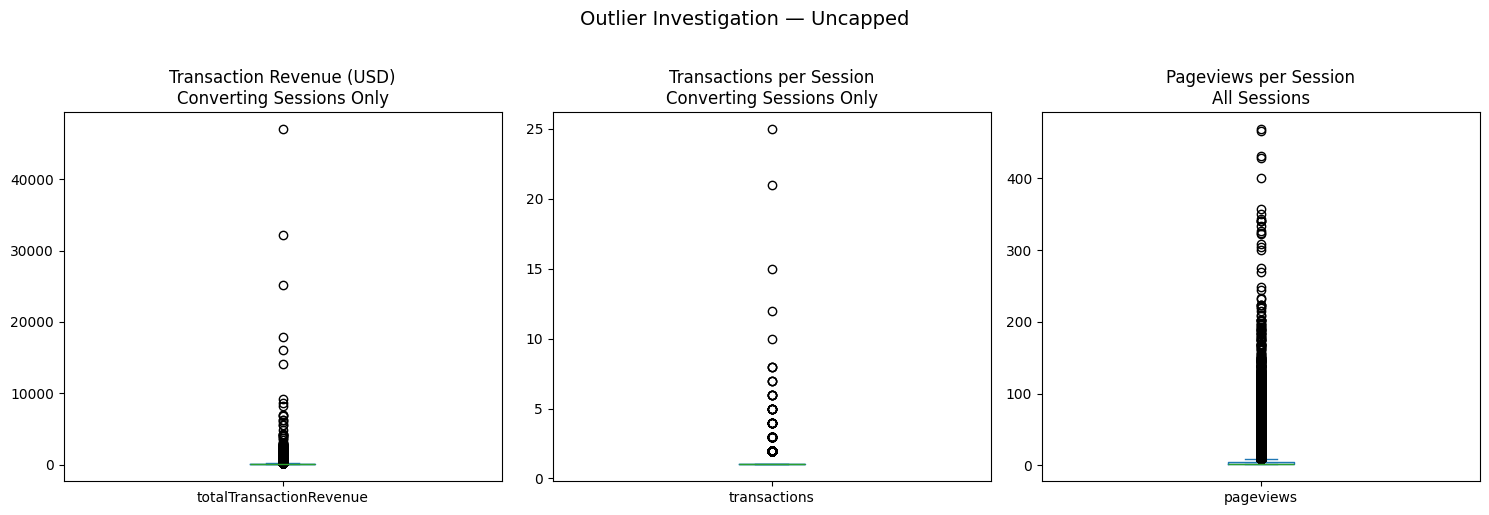

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df_sessions['totalTransactionRevenue'].dropna().plot(
    kind='box', ax=axes[0], title='Transaction Revenue (USD)\nConverting Sessions Only'
)

df_sessions['transactions'].dropna().plot(
    kind='box', ax=axes[1], title='Transactions per Session\nConverting Sessions Only'
)

df_sessions['pageviews'].dropna().plot(
    kind='box', ax=axes[2], title='Pageviews per Session\nAll Sessions'
)

plt.suptitle('Outlier Investigation — Uncapped', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

All three distributions are heavily right-skewed, with extreme outliers compressing the interquartile range to near zero on the y-axis — making the underlying distributions unreadable at this scale. The plots confirm the presence of extreme values in all three metrics:

- **Transaction revenue** — outliers extend to approximately USD 47,000
- **Transactions per session** — outliers extend to approximately 25
- **Pageviews per session** — outliers extend to approximately 469

To decide whether these extreme values represent legitimate behaviour or data quality issues, each metric is investigated in more detail below.

###3.5.3 Outlier Distribution

To understand the scale of the extreme values, the number of sessions exceeding the upper IQR boundary (Q3 + 1.5 × IQR) is calculated for each metric. This is the standard statistical definition of an outlier, and also what the box plot whiskers represent.

In [ ]:
def count_outliers(series):
    series = series.dropna()
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[series > upper_bound]
    return len(outliers), upper_bound, len(outliers) / len(series) * 100

for col in ['totalTransactionRevenue', 'transactions', 'pageviews']:
    count, bound, pct = count_outliers(df_sessions[col])
    print(f"{col}: {count} outliers above {bound:.2f} ({pct:.2f}% of non-null values)")

totalTransactionRevenue: 1400 outliers above 246.55 (12.16% of non-null values)
transactions: 353 outliers above 1.00 (3.06% of non-null values)
pageviews: 95387 outliers above 8.50 (10.56% of non-null values)


The IQR method flags a significant number of sessions as outliers across all three metrics. However, the scale of these numbers — particularly 95,387 sessions for pageviews and 1,400 for revenue — suggests these are not anomalies in the traditional sense, but rather the natural long tail of heavily right-skewed distributions typical of e-commerce data.

Notably, the upper bound for transactions is 1.00 — meaning the IQR method flags any session with more than 1 transaction as an outlier. This reflects the fact that the vast majority of sessions result in exactly 1 transaction, making multiple transactions statistically unusual but not implausible.

Rather than removing these sessions wholesale, the extreme values are investigated further below to determine whether specific sessions at the very top of each distribution warrant removal.

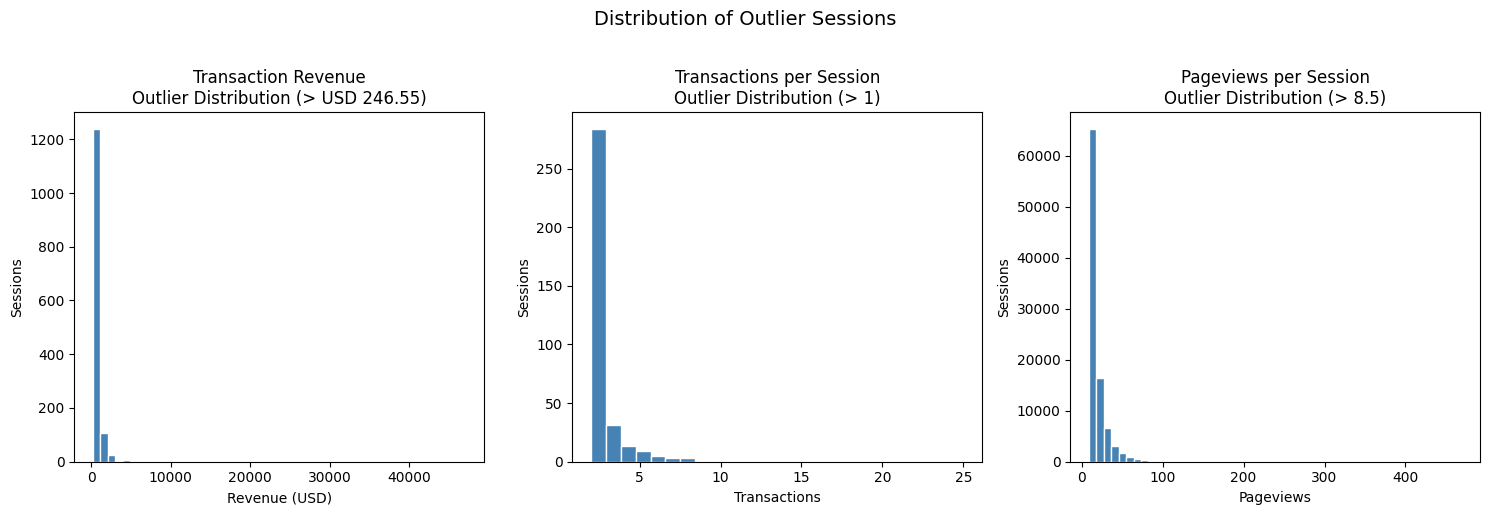

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Revenue outliers only
revenue_outliers = df_sessions[df_sessions['totalTransactionRevenue'] > 246.55]['totalTransactionRevenue']
axes[0].hist(revenue_outliers, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Transaction Revenue\nOutlier Distribution (> USD 246.55)')
axes[0].set_xlabel('Revenue (USD)')
axes[0].set_ylabel('Sessions')

# Transactions outliers only
transaction_outliers = df_sessions[df_sessions['transactions'] > 1]['transactions']
axes[1].hist(transaction_outliers, bins=25, color='steelblue', edgecolor='white')
axes[1].set_title('Transactions per Session\nOutlier Distribution (> 1)')
axes[1].set_xlabel('Transactions')
axes[1].set_ylabel('Sessions')

# Pageviews outliers only
pageview_outliers = df_sessions[df_sessions['pageviews'] > 8.5]['pageviews']
axes[2].hist(pageview_outliers, bins=50, color='steelblue', edgecolor='white')
axes[2].set_title('Pageviews per Session\nOutlier Distribution (> 8.5)')
axes[2].set_xlabel('Pageviews')
axes[2].set_ylabel('Sessions')

plt.suptitle('Distribution of Outlier Sessions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### Conclusion — Outlier Investigation

Investigation of the four flagged anomalies leads to the following decisions:

**Null pageviews (100 sessions)**
Inspection revealed no systematic pattern — sessions span multiple channels, countries and devices with no transactions present. These are isolated tracking errors where GA received hits without a corresponding pageview. As they represent 0.01% of total sessions, they will be removed in the data cleaning step.

**Transaction revenue, transactions per session, and pageviews per session**
The IQR method flags a large number of sessions as outliers across all three metrics. However, histogram analysis reveals that all three follow a natural Pareto distribution — the vast majority of sessions are concentrated at low values, with counts declining smoothly and thinning to isolated individual sessions at the extreme end. No suspicious patterns were identified — no clustering at specific values, no sudden spikes, and no flat tails.

These sessions will be retained in the dataset. However, given the right-skewed nature of all three distributions, median-based metrics will be preferred over means throughout the analysis to avoid distortion from extreme values.

## 4. Data Cleaning

Based on the data quality assessment, the following cleaning steps are applied:

**Columns dropped**
- `language`, `screenResolution`, `cityId`, `latitude`, `longitude`, `networkLocation` — entirely obfuscated in the demo dataset, no analytical value
- `campaignCode` — 903,652 out of 903,653 values are null, single populated value offers no analytical value
- `visits` — always 1 across all sessions, adds no information

**Rows removed**
- 100 sessions with null `pageviews` — isolated tracking errors with no systematic pattern, confirmed no transactions present

**Type conversions**
- `date` — converted from string to datetime
- `visitStartTime` — converted from Unix timestamp to datetime

No outlier removal is applied. Investigation confirmed that extreme values in revenue, transactions and pageviews follow a natural Pareto distribution. Median-based metrics are used throughout the analysis to account for the right-skewed distributions.

In [ ]:
cols_to_drop = [
    'language',
    'screenResolution',
    'cityId',
    'latitude',
    'longitude',
    'networkLocation',
    'campaignCode',
    'visits'
]

df_sessions = df_sessions.drop(columns=cols_to_drop)
print(f'Columns after drop: {df_sessions.shape[1]}')

Columns after drop: 38


In [ ]:
df_sessions = df_sessions[df_sessions['pageviews'].notna()]
print(f'Rows after removing null pageviews: {df_sessions.shape[0]}')

Rows after removing null pageviews: 903553


In [ ]:
df_sessions['date'] = pd.to_datetime(df_sessions['date'], format='%Y%m%d')
df_sessions['visitStartTime'] = pd.to_datetime(df_sessions['visitStartTime'], unit='s')

print(df_sessions[['date', 'visitStartTime']].dtypes)
print(df_sessions[['date', 'visitStartTime']].head(3))

date              datetime64[ns]
visitStartTime     datetime64[s]
dtype: object
        date      visitStartTime
0 2016-10-23 2016-10-23 09:40:37
1 2016-10-23 2016-10-24 03:22:48
2 2016-10-23 2016-10-23 21:44:38


All cleaning steps applied successfully:

- 8 columns dropped — 38 columns remaining
- 100 null pageview rows removed — 903,553 sessions remaining
- `date` and `visitStartTime` converted to datetime

The dataset is now ready for analysis.

## 5. Analysis

The analysis begins with a regression to identify which session-level variables most explain revenue per session. This ensures subsequent sections focus on the most analytically significant dimensions rather than examining every available variable based on intuition.

Subsequent analysis sections are determined by the regression findings.

Throughout the analysis, median-based metrics are preferred over means to account for the right-skewed revenue distribution identified in the data quality assessment. All revenue figures are in USD.

### 5.1 Revenue Drivers — Regression Analysis

Before drilling into individual dimensions, a linear regression is run to identify which session-level variables most explain revenue per session. This guides the focus of the subsequent analysis — rather than examining every available dimension, attention is directed towards the variables with the strongest explanatory power.

Revenue per session is used as the dependent variable, with null values (non-converting sessions) filled with 0. This captures both the probability of conversion and order value in a single metric, making it directly relevant for channel budget decisions.

Independent variables included:
- **Categorical:** channel, device category, sales region, new vs returning visitor, bounced vs non-bounced
- **Continuous:** pageviews, time on site, session quality score

Categorical variables are one-hot encoded prior to modelling. Coefficients are standardised to allow comparison across variables of different scales.

#### 5.1.1 Correlation Matrix

Before running the regression, a correlation matrix of continuous variables is examined to identify multicollinearity — highly correlated independent variables can distort regression coefficients and make individual variable contributions unreliable.

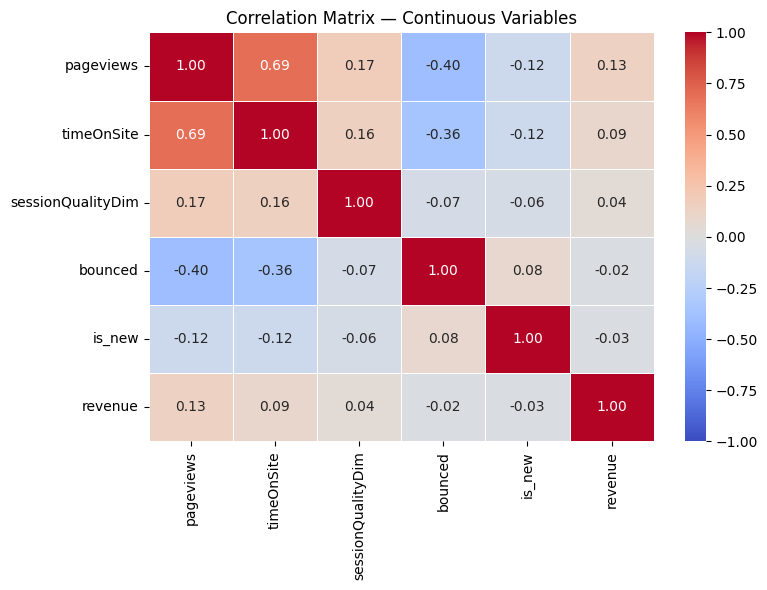

In [ ]:
# Prepare dataset
df_reg = df_sessions.copy().reset_index(drop=True)

# Fill null revenue with 0
df_reg['revenue'] = df_reg['totalTransactionRevenue'].fillna(0)

# Fill null timeOnSite with 0
df_reg['timeOnSite'] = df_reg['timeOnSite'].fillna(0)

# Convert binary flags to 0/1
df_reg['bounced'] = df_reg['bounces'].notna().astype(int)
df_reg['is_new'] = df_reg['newVisits'].notna().astype(int)

# Fill null sessionQualityDim with 0
df_reg['sessionQualityDim'] = df_reg['sessionQualityDim'].fillna(0)

# Fill null sales_region with 'Unknown'
df_reg['sales_region'] = df_reg['sales_region'].fillna('Unknown')

# One-hot encode categorical variables
df_reg = pd.get_dummies(df_reg, columns=['channelGrouping', 'deviceCategory', 'sales_region'], drop_first=True)

# Select features
feature_cols = (
    [c for c in df_reg.columns if c.startswith('channelGrouping_')] +
    [c for c in df_reg.columns if c.startswith('deviceCategory_')] +
    [c for c in df_reg.columns if c.startswith('sales_region_')] +
    ['pageviews', 'timeOnSite', 'sessionQualityDim', 'bounced', 'is_new']
)

X = df_reg[feature_cols].fillna(0)
y = df_reg['revenue']

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

continuous_vars = ['pageviews', 'timeOnSite', 'sessionQualityDim', 'bounced', 'is_new', 'revenue']

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    df_reg[continuous_vars].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    ax=ax,
    linewidths=0.5,
    vmin=-1,
    vmax=1
)
ax.set_title('Correlation Matrix — Continuous Variables')
plt.tight_layout()
plt.show()

The strongest correlation is between `pageviews` and `timeOnSite` (0.69) — expected, as more pages viewed naturally leads to more time on site. Negative correlations between `bounces` and both `pageviews` (−0.40) and `timeOnSite` (−0.36) also reflect expected behaviour — bounced sessions have fewer pageviews and less time on site by definition.

No correlations exceed 0.8, meaning multicollinearity is not severe enough to warrant excluding any variable. All continuous variables are retained for the regression.

#### 5.1.2 Linear Regression — Revenue Drivers

In [ ]:
# Run F-test
f_stats, p_values = f_regression(X_scaled, y)

# Create results dataframe
f_results = pd.DataFrame({
    'variable': feature_cols,
    'f_statistic': f_stats,
    'p_value': p_values
})

# Assign group labels
def get_group(var):
    if var.startswith('channelGrouping_'): return 'channelGrouping'
    if var.startswith('deviceCategory_'): return 'deviceCategory'
    if var.startswith('sales_region_'): return 'sales_region'
    return var

f_results['group'] = f_results['variable'].apply(get_group)

# Aggregate by group
group_importance = f_results.groupby('group').agg(
    mean_f_statistic=('f_statistic', 'mean'),
    min_p_value=('p_value', 'min')
).sort_values('mean_f_statistic', ascending=False)

print("Feature Importance by Group (F-test):")
print(group_importance.to_string())
print("\nIndividual Variable Results:")
print(f_results.sort_values('f_statistic', ascending=False).to_string())

Feature Importance by Group (F-test):
                   mean_f_statistic    min_p_value
group                                             
pageviews              16569.657887   0.000000e+00
timeOnSite              7545.508824   0.000000e+00
sessionQualityDim       1514.901415   0.000000e+00
is_new                   815.616282  2.611710e-179
bounced                  504.859516  8.940983e-112
sales_region             160.246206  2.859045e-125
channelGrouping          150.328136   1.112237e-90
deviceCategory            62.355442   2.056392e-26

Individual Variable Results:
                          variable   f_statistic        p_value              group
14                       pageviews  16569.657887   0.000000e+00          pageviews
15                      timeOnSite   7545.508824   0.000000e+00         timeOnSite
16               sessionQualityDim   1514.901415   0.000000e+00  sessionQualityDim
18                          is_new    815.616282  2.611710e-179             is_new
11     

#### Regression Results

The F-test results reveal the relative importance of each variable group in explaining revenue per session:

**Engagement metrics dominate**
Pageviews and time on site are by far the strongest predictors of revenue — sessions with more pageviews and longer dwell time are significantly more likely to generate revenue. Session quality score (Google's own engagement metric) is the third strongest predictor. Note that pageviews and time on site are correlated (0.69), meaning they partly measure the same underlying behaviour — engagement depth. While statistically strong, these metrics are largely descriptive — engaged visitors convert more almost by definition. They are therefore not investigated further as standalone dimensions.

**Visitor type matters**
New visitors and bounced sessions are both significant predictors. The visitor type dimension is explored further in section 5.2, with a focus on which channels build returning visitor loyalty — a directly actionable insight for the CMO.

**Geography and channel are roughly equal**
Sales region and channel grouping explain roughly equal variance in revenue per session. Both are examined together in section 5.3, where channel performance is analysed globally and then broken down regionally.

**Channel findings**
Within channelGrouping, Referral and Display are the strongest individual predictors. Paid Search has an F-statistic of 0.03 and a p-value of 0.86 — virtually no independent explanatory power on revenue per session.

**Device is the weakest driver**
Device category has the lowest group F-statistic and is not investigated further as a standalone dimension.

The subsequent analysis follows the order suggested by the regression: <br>5.2 examines visitor type in detail <br> 5.3 investigates channel performance globally and by region.

### 5.2 Visitor Type — New vs Returning

The regression identified visitor type as a significant revenue driver. Before examining which channels build returning visitor loyalty, the revenue value of returning visitors is established — if returning visitors do not generate meaningfully higher expected revenue per session, channel loyalty becomes a less strategic consideration.

Expected revenue per session (conversion rate × median revenue per converting session) is used as the primary metric, capturing both conversion probability and order value in a single number.

In [ ]:
# Create new vs returning flag
df_sessions['visitor_type'] = df_sessions['newVisits'].apply(
    lambda x: 'New' if pd.notna(x) else 'Returning'
)

visitor_summary = df_sessions.groupby('visitor_type').agg(
    sessions=('visitId', 'count'),
    converting_sessions=('transactions', 'count'),
    median_revenue=('totalTransactionRevenue', 'median'),
    total_revenue=('totalTransactionRevenue', 'sum')
).reset_index()

visitor_summary['conversion_rate'] = (visitor_summary['converting_sessions'] / visitor_summary['sessions'] * 100).round(2)
visitor_summary['expected_revenue_per_session'] = (visitor_summary['conversion_rate'] / 100 * visitor_summary['median_revenue']).round(2)

print(visitor_summary[['visitor_type', 'sessions', 'conversion_rate', 'median_revenue', 'expected_revenue_per_session']])

  visitor_type  sessions  conversion_rate  median_revenue  \
0          New    703045             0.64          44.790   
1    Returning    200508             3.53          64.135   

   expected_revenue_per_session  
0                          0.29  
1                          2.26  


Returning visitors are substantially more valuable than new visitors across all metrics:

- **Conversion rate:** 3.53% vs 0.64% — returning visitors convert at 5.5x the rate of new visitors
- **Median order value:** USD 64.14 vs USD 44.79 — returning visitors spend 43% more per transaction
- **Expected revenue per session:** USD 2.26 vs USD 0.29 — returning visitors generate nearly 8x more revenue per session

This establishes that visitor loyalty has significant revenue implications. The natural follow-up question is which channels are most effective at building returning visitor audiences — examined below.

#### 5.2.1 Channel Loyalty — New vs Returning Visitor Split

Given that returning visitors generate nearly 8x more revenue per session, understanding which channels attract the most loyal audiences is directly actionable for budget decisions. The chart below shows the new vs returning visitor split per channel, ordered by returning visitor share.

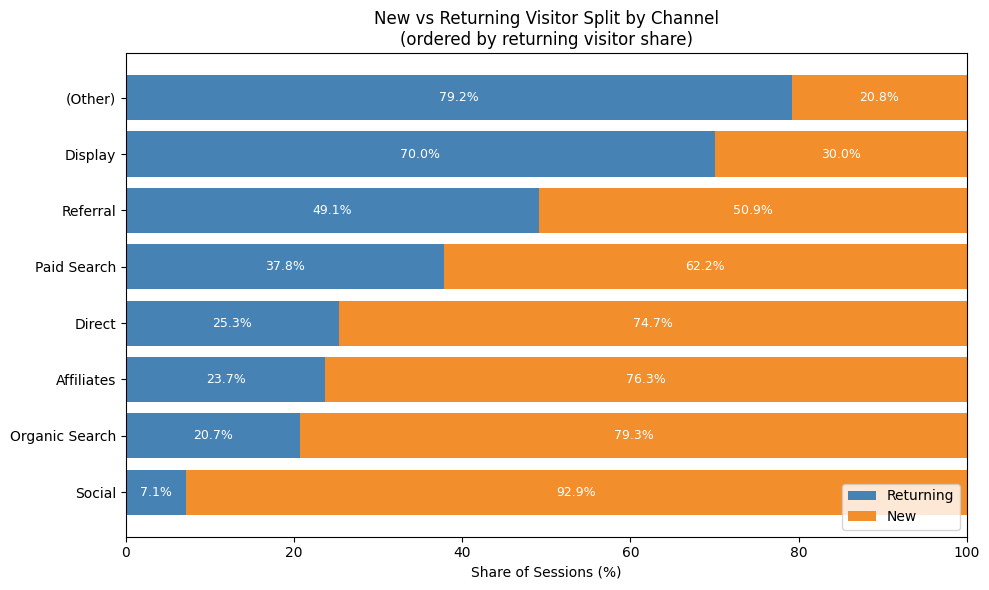

In [ ]:
channel_visitor = df_sessions.groupby(['channelGrouping', 'visitor_type']).agg(
    sessions=('visitId', 'count')
).reset_index()

channel_visitor_pct = channel_visitor.pivot(
    index='channelGrouping',
    columns='visitor_type',
    values='sessions'
).fillna(0)

channel_visitor_pct['total'] = channel_visitor_pct.sum(axis=1)
channel_visitor_pct['returning_pct'] = (channel_visitor_pct['Returning'] / channel_visitor_pct['total'] * 100).round(1)
channel_visitor_pct['new_pct'] = (channel_visitor_pct['New'] / channel_visitor_pct['total'] * 100).round(1)

# Sort by returning percentage
channel_visitor_pct = channel_visitor_pct.sort_values('returning_pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(channel_visitor_pct.index, channel_visitor_pct['returning_pct'],
        color='steelblue', label='Returning')
ax.barh(channel_visitor_pct.index, channel_visitor_pct['new_pct'],
        left=channel_visitor_pct['returning_pct'],
        color='#f28e2b', label='New')

# Add percentage labels
for i, (idx, row) in enumerate(channel_visitor_pct.iterrows()):
    ax.text(row['returning_pct']/2, i, f"{row['returning_pct']}%",
            va='center', ha='center', fontsize=9, color='white')
    ax.text(row['returning_pct'] + row['new_pct']/2, i, f"{row['new_pct']}%",
            va='center', ha='center', fontsize=9, color='white')

ax.set_xlabel('Share of Sessions (%)')
ax.set_title('New vs Returning Visitor Split by Channel\n(ordered by returning visitor share)')
ax.legend(loc='lower right')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

The returning visitor split varies significantly across channels:

- **(Other)** has the highest returning share at 79.2%
- **Display** stands out with 70% returning visitors — suggesting it is being used primarily for retargeting existing audiences rather than acquiring new ones
- **Referral** is almost evenly split at 49% returning — balanced between acquisition and retention
- **Paid Search** is 37.8% returning — more acquisition-focused but with a meaningful returning component
- **Direct** shows 74.7% new visitors — surprisingly high for a channel typically associated with brand loyalty
- **Affiliates and Organic Search** are predominantly new visitor channels at 76.3% and 79.3% respectively
- **Social** is overwhelmingly new visitors at 92.9% — a pure acquisition channel with almost no returning audience

These findings will be revisited in the channel performance section where conversion rates and revenue are examined per channel.

#### 5.2.2 Channel Retention — What Share of Acquired Visitors Return?

In [ ]:
# Total first sessions per channel
total_acquired = df_sessions[df_sessions['visitNumber'] == 1].groupby('channelGrouping')['fullVisitorId'].count().rename('total_acquired')

# Visitors who had at least one return session
returned = df_sessions[df_sessions['visitNumber'] == 2]['fullVisitorId'].unique()

# First sessions where visitor later returned
acquisition_returned = df_sessions[
    (df_sessions['visitNumber'] == 1) &
    (df_sessions['fullVisitorId'].isin(returned))
].groupby('channelGrouping')['fullVisitorId'].count().rename('returned')

# Combine and calculate return rate
retention = pd.concat([total_acquired, acquisition_returned], axis=1).fillna(0)
retention['return_rate'] = (retention['returned'] / retention['total_acquired'] * 100).round(1)
retention = retention.sort_values('return_rate', ascending=False)

print(retention.to_string())

                 total_acquired  returned  return_rate
channelGrouping                                       
(Other)                      25        10         40.0
Display                    1877       559         29.8
Paid Search               15762      4104         26.0
Referral                  53363     13113         24.6
Direct                   106839     19461         18.2
Affiliates                12508      2006         16.0
Organic Search           302631     38526         12.7
Social                   210040      8513          4.1


The return rate ranking closely mirrors the returning visitor share ranking from the previous analysis. This consistency is itself a finding — it suggests that channels are largely self-reinforcing: visitors acquired via a channel tend to return through the same channel. If channel-switching were common, the two rankings would diverge significantly. Social remains the clear outlier at both ends — lowest returning visitor share and lowest return rate.

The next step examines this hypothesis directly — whether returning visitors predominantly return through the same channel they were acquired through.

####5.2.3 Channel Flow — Where Do Returning Visitors Go?

Having established that returning visitors are significantly more valuable and that channels vary in their ability to retain them, the next question is whether returning visitors stay within the same channel or switch. The matrix below shows, for each acquisition channel, what percentage of return sessions occur through each channel.

In [ ]:
# Get acquisition channel (visitNumber == 1)
acquisition = df_sessions[df_sessions['visitNumber'] == 1][['fullVisitorId', 'channelGrouping']].rename(
    columns={'channelGrouping': 'acquisition_channel'})

# Get return sessions (visitNumber > 1)
returning = df_sessions[df_sessions['visitNumber'] > 1][['fullVisitorId', 'channelGrouping']].rename(
    columns={'channelGrouping': 'return_channel'})

# Join
journeys = acquisition.merge(returning, on='fullVisitorId')

# Count combinations
journey_counts = journeys.groupby(['acquisition_channel', 'return_channel']).size().reset_index(name='count')

# Normalise by total return sessions per acquisition channel
total_returns = journey_counts.groupby('acquisition_channel')['count'].sum().rename('total_returns')
journey_counts = journey_counts.merge(total_returns, on='acquisition_channel')
journey_counts['pct'] = (journey_counts['count'] / journey_counts['total_returns'] * 100).round(1)

# Pivot to matrix
journey_matrix = journey_counts.pivot(
    index='acquisition_channel',
    columns='return_channel',
    values='pct'
).fillna(0)

print(journey_matrix.to_string())

return_channel       (Other)  Affiliates  Direct  Display  Organic Search  Paid Search  Referral  Social
acquisition_channel                                                                                     
(Other)                 47.4        21.1     0.0     10.5             5.3          0.0      15.8     0.0
Affiliates               0.0        67.8     0.1      0.0             9.1          0.4      22.0     0.5
Direct                   0.0         1.0    66.4      1.6            12.9          2.0      14.0     2.1
Display                  0.2         0.1     1.0     48.8            28.6          5.8      15.5     0.1
Organic Search           0.0         0.8     0.4      2.1            84.5          3.8       7.1     1.3
Paid Search              0.0         0.1     0.2      4.4            33.9         58.1       2.8     0.4
Referral                 0.0         0.6     0.3      1.3             6.0          0.6      90.0     1.1
Social                   0.0         0.1     0.1      0

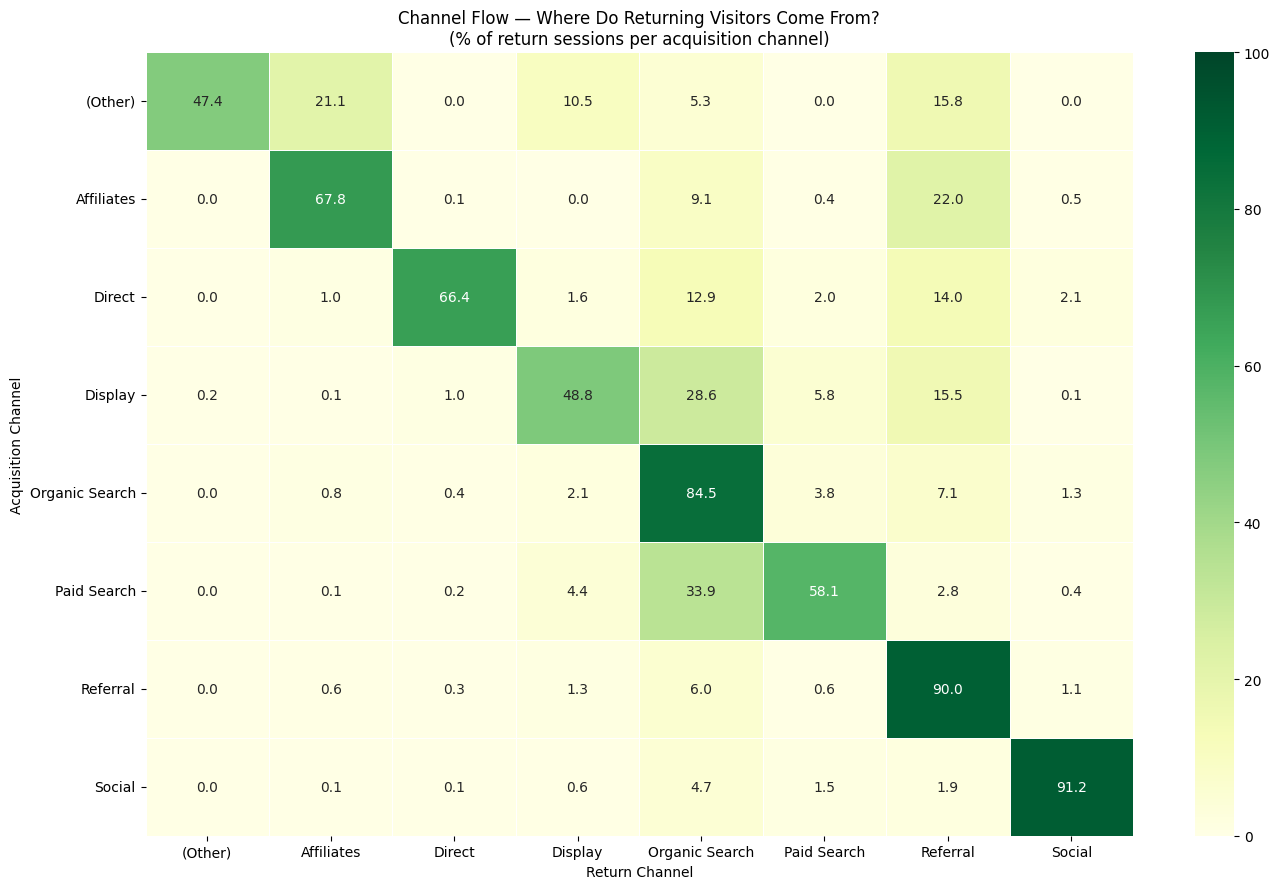

In [ ]:
# Get acquisition channel (visitNumber == 1)
acquisition = df_sessions[df_sessions['visitNumber'] == 1][['fullVisitorId', 'channelGrouping']].rename(
    columns={'channelGrouping': 'acquisition_channel'})

# Get return sessions (visitNumber > 1)
returning = df_sessions[df_sessions['visitNumber'] > 1][['fullVisitorId', 'channelGrouping']].rename(
    columns={'channelGrouping': 'return_channel'})

# Join
journeys = acquisition.merge(returning, on='fullVisitorId')

# Count combinations
journey_counts = journeys.groupby(['acquisition_channel', 'return_channel']).size().reset_index(name='count')

# Normalise by total return sessions per acquisition channel
total_returns = journey_counts.groupby('acquisition_channel')['count'].sum().rename('total_returns')
journey_counts = journey_counts.merge(total_returns, on='acquisition_channel')
journey_counts['pct'] = (journey_counts['count'] / journey_counts['total_returns'] * 100).round(1)

fig, ax = plt.subplots(figsize=(14, 9))

sns.heatmap(
    journey_matrix,
    annot=True,
    fmt='.1f',
    cmap='YlGn',
    ax=ax,
    linewidths=0.5,
    vmin=0,
    vmax=100
)

ax.set_title('Channel Flow — Where Do Returning Visitors Come From?\n(% of return sessions per acquisition channel)', fontsize=12)
ax.set_xlabel('Return Channel')
ax.set_ylabel('Acquisition Channel')
plt.tight_layout()
plt.show()

The heatmap reveals two distinct patterns:

**Channels are largely self-reinforcing**
The diagonal dominates across all channels — visitors acquired via a channel predominantly return through the same channel. This is strongest for Social (91.2%), Referral (90.0%) and Organic Search (84.5%), and weakest for Display (48.8%) which shows more cross-channel return behaviour.

**Organic Search and Referral act as destination channels**
Beyond the diagonal, Organic Search and Referral stand out as frequent return destinations across almost all acquisition channels. Visitors first acquired via Display, Direct, Paid Search or Social all show a meaningful percentage returning through Organic Search or Referral. This suggests that as visitors grow more familiar with the store, they increasingly return through high-intent channels — actively searching for it or navigating via a trusted link — regardless of how they originally discovered it.

**Affiliates receives a disproportionate share from (Other)**
21.1% of (Other)-acquired visitors return via Affiliates — an unusual flow that is difficult to interpret without knowing the composition of the (Other) category.

Note: percentages are relative to each acquisition channel's total return sessions and cannot be summed across rows.

#### Visitor Type — Summary

The three analyses above paint a coherent picture of visitor loyalty and its revenue implications.

Returning visitors generate nearly 8x more expected revenue per session than new visitors (USD 2.26 vs USD 0.29), establishing that loyalty is a significant revenue driver. However, channels vary dramatically in their ability to build that loyalty — Display and Paid Search retain nearly 30% of acquired visitors for a return visit, while Social retains just 4.1% despite being the second largest acquisition channel by volume.

When returning visitors do come back, they predominantly return through the same channel they were acquired through — suggesting that channel loyalty and visitor loyalty are closely linked. The exception is Organic Search and Referral, which act as destination channels, drawing returning visitors from across all acquisition sources. This reflects a natural progression: visitors who discovered the store via another channel eventually return by actively searching for it or navigating via a trusted link — a signal of growing brand familiarity and purchase intent.

Taken together, these findings suggest that channel investment decisions should account not just for first-visit conversion but for a channel's ability to build a returning, high-value audience.

### 5.3 Channel Performance

**Business question:** Which marketing channels drive the most valuable sessions, and where should budget be reallocated?

The channel performance analysis evaluates each channel across four dimensions: traffic volume, conversion rate, revenue contribution, and engagement quality. Each metric tells a different part of the story — a high-volume channel with low conversion may warrant a different budget decision than a low-volume channel with high average order value.

The analysis is presented at global level first, followed by a regional breakdown.

#### Channel Performance — Summary Table

The table below summarises all eight channels across session volume, conversion rate, bounce rate, engagement and revenue metrics. All revenue figures are in USD. Median-based metrics are used throughout to account for the right-skewed revenue distribution identified in the data quality assessment.



In [ ]:
print("=" * 70)
print("5.3 CHANNEL PERFORMANCE — GLOBAL OVERVIEW")
print("=" * 70)

channel_summary = df_sessions.groupby('channelGrouping').agg(
    sessions=('visitId', 'count'),
    converting_sessions=('transactions', 'count'),
    total_revenue=('totalTransactionRevenue', 'sum'),
    median_revenue_converting=('totalTransactionRevenue', 'median'),
    bounces=('bounces', 'count'),
    median_pageviews=('pageviews', 'median')
).sort_values('sessions', ascending=False)

# Calculated fields
channel_summary['sessions_pct'] = (channel_summary['sessions'] / channel_summary['sessions'].sum() * 100).round(1)
channel_summary['conversion_rate'] = (channel_summary['converting_sessions'] / channel_summary['sessions'] * 100).round(2)
channel_summary['bounce_rate'] = (channel_summary['bounces'] / channel_summary['sessions'] * 100).round(1)
channel_summary['revenue_share'] = (channel_summary['total_revenue'] / channel_summary['total_revenue'].sum() * 100).round(1)
channel_summary['expected_revenue_per_session'] = (channel_summary['conversion_rate'] / 100 * channel_summary['median_revenue_converting']).round(2)

print(channel_summary[[
    'sessions', 'sessions_pct', 'conversion_rate',
    'bounce_rate', 'median_pageviews',
    'total_revenue', 'revenue_share',
    'median_revenue_converting', 'expected_revenue_per_session'
]])

5.3 CHANNEL PERFORMANCE — GLOBAL OVERVIEW
                 sessions  sessions_pct  conversion_rate  bounce_rate  \
channelGrouping                                                         
Organic Search     381530          42.2              0.9         48.3   
Social             226102          25.0             0.05         65.2   
Direct             143002          15.8             1.44         49.6   
Referral           104811          11.6             5.08         26.0   
Paid Search         25325           2.8             1.85         38.0   
Affiliates          16401           1.8             0.05         53.1   
Display              6262           0.7             2.28         35.9   
(Other)               120           0.0             0.83         46.7   

                 median_pageviews  total_revenue  revenue_share  \
channelGrouping                                                   
Organic Search                2.0      377075.81           21.2   
Social                    

#### 5.3.1 Session Distribution

The donut chart below shows how total sessions are distributed across channels.

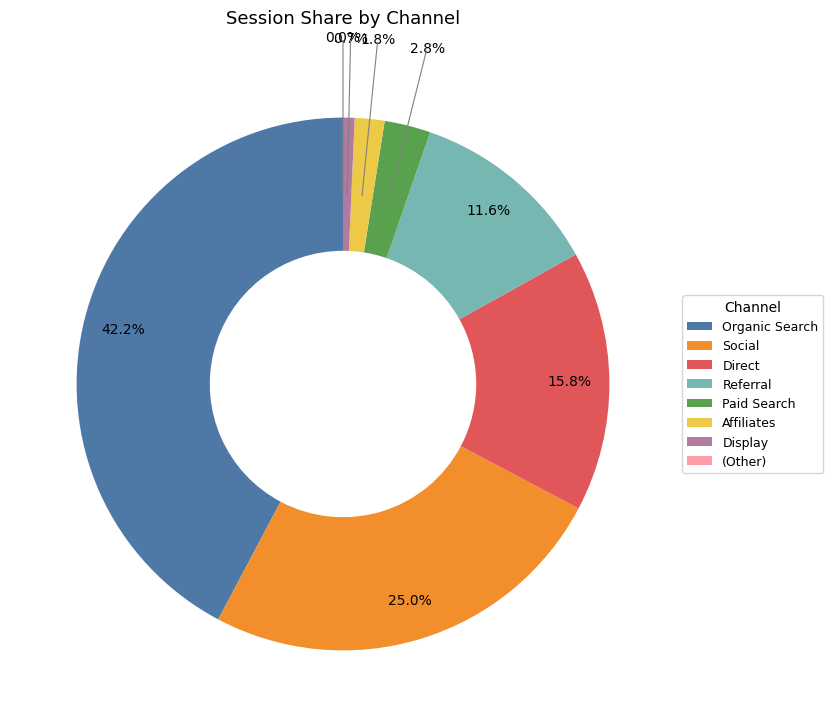

In [ ]:
fig, ax = plt.subplots(figsize=(12, 9))
fig.subplots_adjust(top=0.85)  # add this line

colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#edc948', '#b07aa1', '#ff9da7']

wedges, texts, autotexts = ax.pie(
    channel_summary['sessions_pct'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.5),
    pctdistance=0.85,
    colors=colors
)

for i, (wedge, autotext) in enumerate(zip(wedges, autotexts)):
    if channel_summary['sessions_pct'].iloc[i] < 3:
        angle = (wedge.theta1 + wedge.theta2) / 2
        x = 1.3 * np.cos(np.radians(angle))
        y = 1.3 * np.sin(np.radians(angle))
        autotext.set_position((x, y))
        ax.annotate('', xy=(0.7 * np.cos(np.radians(angle)),
                             0.7 * np.sin(np.radians(angle))),
                    xytext=(x, y),
                    arrowprops=dict(arrowstyle='-', color='grey', lw=0.8))

ax.legend(wedges, channel_summary.index,
          title='Channel', loc='center left',
          bbox_to_anchor=(1, 0, 0.5, 1), fontsize=9)

ax.set_title('Session Share by Channel', fontsize=13, pad=20)
plt.show()

Organic Search dominates traffic at 42.2% of sessions, followed by Social at 25% — a surprisingly large share for a merchandise store. Paid channels (Paid Search, Display, Affiliates) collectively account for just 5.3% of sessions, likely a deliberate choice given Google's strong organic presence. Direct and Referral combined represent 27.4%, suggesting a loyal returning audience and strong word-of-mouth.

#### 5.3.2 Channel Performance Overview

The bubble chart below plots session share against revenue share for each channel. Channels above the diagonal generate proportionally more revenue than their session share — overperformers. Channels below are underperformers. Bubble size represents total absolute revenue, showing strategic importance regardless of relative efficiency.

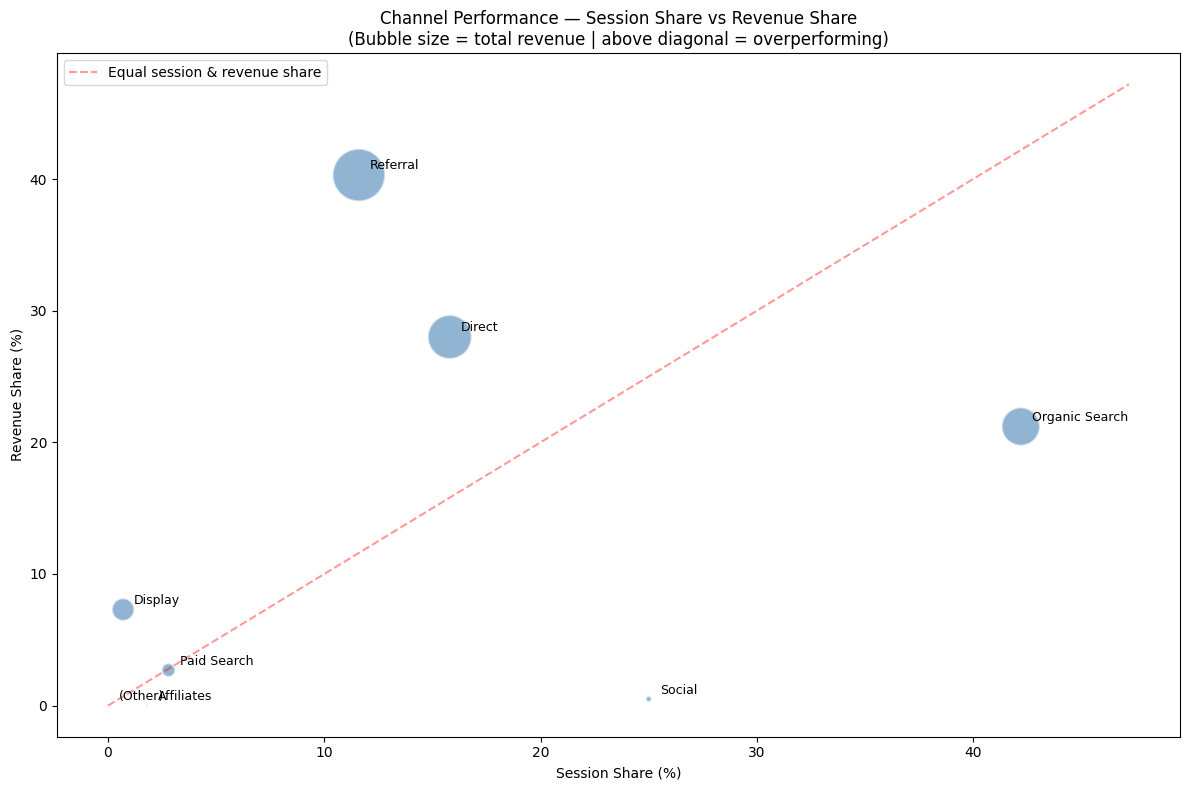

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

x = channel_summary['sessions_pct']
y = channel_summary['revenue_share']
size = channel_summary['total_revenue'] / 500

ax.scatter(x, y, s=size, alpha=0.6, color='steelblue', edgecolors='white', linewidth=1.5)
max_val = max(x.max(), y.max()) + 5
ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.4, label='Equal session & revenue share')

for channel in channel_summary.index:
    ax.annotate(channel,
                xy=(channel_summary.loc[channel, 'sessions_pct'],
                    channel_summary.loc[channel, 'revenue_share']),
                xytext=(8, 4), textcoords='offset points', fontsize=9)

ax.set_xlabel('Session Share (%)')
ax.set_ylabel('Revenue Share (%)')
ax.set_title('Channel Performance — Session Share vs Revenue Share\n(Bubble size = total revenue | above diagonal = overperforming)')
ax.legend()
plt.tight_layout()
plt.show()

Referral and Direct are clear overperformers — both sit well above the diagonal with large bubbles, confirming they drive disproportionate revenue relative to their session share. Display also overperforms but remains small in absolute terms. Organic Search is the most significant underperformer — the largest channel by sessions but generating only 21.2% of revenue. Social is the most extreme underperformer, with 25% of sessions but just 0.5% of revenue. Paid Search sits close to the diagonal — performing proportionally to its session share. Affiliates underperforms clearly. (Other) is negligible on both dimensions.

#### 5.3.3 Engagement & Conversion Relationships

Three scatter plots examine relationships between engagement metrics and conversion behaviour across channels. Each dot represents one channel.

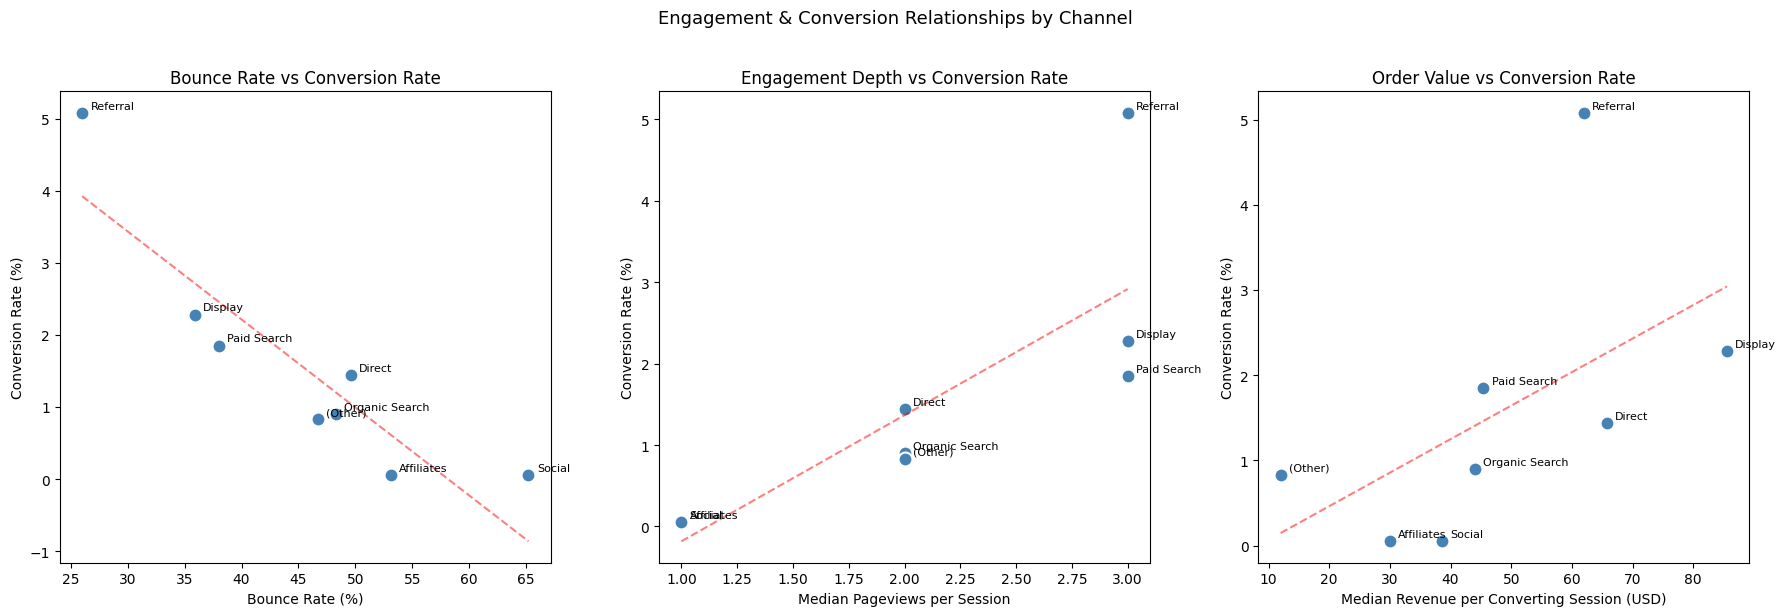

In [ ]:
from numpy.polynomial.polynomial import polyfit
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

def add_trendline(ax, x, y):
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, p(x_line), 'r--', alpha=0.5, linewidth=1.5)

channels = channel_summary.index

# Chart 1 — Bounce rate vs Conversion rate
x1 = channel_summary['bounce_rate']
y1 = channel_summary['conversion_rate']
axes[0].scatter(x1, y1, color='steelblue', s=100, edgecolors='white', linewidth=1.5)
add_trendline(axes[0], x1, y1)
for channel in channels:
    axes[0].annotate(channel, xy=(channel_summary.loc[channel, 'bounce_rate'],
                     channel_summary.loc[channel, 'conversion_rate']),
                     xytext=(6, 3), textcoords='offset points', fontsize=8)
axes[0].set_xlabel('Bounce Rate (%)')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_title('Bounce Rate vs Conversion Rate')

# Chart 2 — Median pageviews vs Conversion rate
x2 = channel_summary['median_pageviews']
y2 = channel_summary['conversion_rate']
axes[1].scatter(x2, y2, color='steelblue', s=100, edgecolors='white', linewidth=1.5)
add_trendline(axes[1], x2, y2)
for channel in channels:
    axes[1].annotate(channel, xy=(channel_summary.loc[channel, 'median_pageviews'],
                     channel_summary.loc[channel, 'conversion_rate']),
                     xytext=(6, 3), textcoords='offset points', fontsize=8)
axes[1].set_xlabel('Median Pageviews per Session')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_title('Engagement Depth vs Conversion Rate')

# Chart 3 — Median revenue per converting session vs Conversion rate
x3 = channel_summary['median_revenue_converting']
y3 = channel_summary['conversion_rate']
axes[2].scatter(x3, y3, color='steelblue', s=100, edgecolors='white', linewidth=1.5)
add_trendline(axes[2], x3, y3)
for channel in channels:
    axes[2].annotate(channel, xy=(channel_summary.loc[channel, 'median_revenue_converting'],
                     channel_summary.loc[channel, 'conversion_rate']),
                     xytext=(6, 3), textcoords='offset points', fontsize=8)
axes[2].set_xlabel('Median Revenue per Converting Session (USD)')
axes[2].set_ylabel('Conversion Rate (%)')
axes[2].set_title('Order Value vs Conversion Rate')

plt.suptitle('Engagement & Conversion Relationships by Channel', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Three relationships emerge from the scatter plots:

**Bounce rate vs Conversion rate** — a clear negative relationship: channels with higher bounce rates convert less. This holds across all channels with Referral as a mild outlier, sitting slightly above the trendline.

**Engagement depth vs Conversion rate** — a strong positive relationship: more pageviews per session correlates with higher conversion. Referral is a significant outlier, converting far above what its median pageview count would predict. This suggests Referral visitors arrive with stronger purchase intent — pre-qualified by the source before landing on the store.

**Order value vs Conversion rate** — a positive but more scattered relationship. Referral again sits well above the trendline.

Referral is the standout channel across all three charts — it consistently outperforms the trend. The likely explanation: Referral traffic arrives via trusted external sources (review sites, partner pages, Google properties) and lands with a higher degree of purchase intent than traffic from other channels.

#### 5.3.4 Regional Breakdown

The global channel findings are examined across sales regions to identify where patterns diverge. A heatmap of conversion rate by channel and region reveals regional variations at a glance.

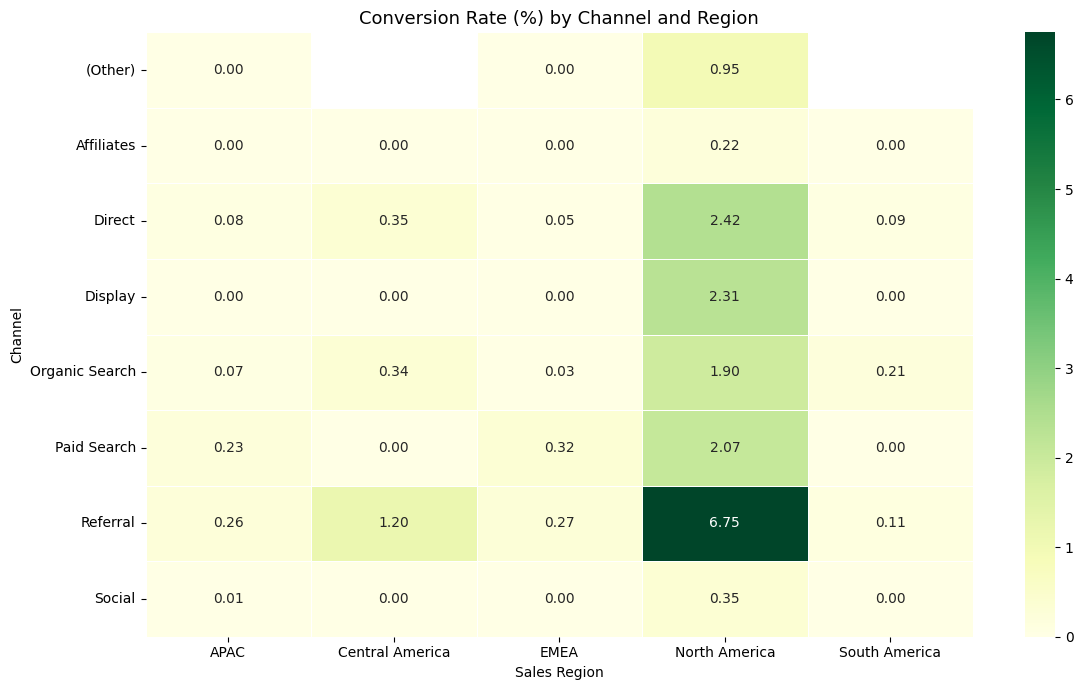

In [ ]:
# Filter out null sales_region
df_regional = df_sessions[df_sessions['sales_region'].notna()]

regional_summary = df_regional.groupby(['sales_region', 'channelGrouping']).agg(
    sessions=('visitId', 'count'),
    converting_sessions=('transactions', 'count'),
).reset_index()

regional_summary['conversion_rate'] = (regional_summary['converting_sessions'] / regional_summary['sessions'] * 100).round(2)

# Pivot for heatmap
heatmap_data = regional_summary.pivot(index='channelGrouping', columns='sales_region', values='conversion_rate')

import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(heatmap_data.astype(float), annot=True, fmt='.2f', cmap='YlGn', ax=ax, linewidths=0.5)
ax.set_title('Conversion Rate (%) by Channel and Region', fontsize=13)
ax.set_xlabel('Sales Region')
ax.set_ylabel('Channel')
plt.tight_layout()
plt.show()

The heatmap confirms that channel performance patterns are almost entirely a North American story. Key observations:

- **North America** is the only region with meaningful conversion rates across multiple channels
- **Referral** is the top converting channel in North America, consistent with the global finding
- **EMEA and APAC** show near-zero conversion across all channels — confirming the structural barrier is market-wide, not channel-specific
- **South America** shows higher conversion for Organic Search than Referral — a divergence from the global pattern, though with only 15 total conversions conclusions must be treated with caution
- **Central America** shows a relatively high Referral conversion rate (1.2%) but session volume is too small for reliable conclusions



To understand whether the near-zero conversion rates outside North America reflect data scarcity or a genuine structural barrier, session and conversion counts are examined at region level.

In [ ]:
print(df_regional.groupby('sales_region').agg(
    sessions=('visitId', 'count'),
    conversions=('transactions', 'count')
).assign(conversion_rate=lambda x: (x['conversions']/x['sessions']*100).round(2)))

                 sessions  conversions  conversion_rate
sales_region                                           
APAC               112921           81             0.07
Central America     13218           20             0.15
EMEA               170173           66             0.04
North America      390472        11194             2.87
South America       24808           15             0.06


Regional conversion rates reveal a striking pattern: North America converts at 2.87% while all other regions sit below 0.15% despite significant session volumes — EMEA alone contributes 170,173 sessions at just 0.04% conversion.

This is unlikely to be a data quality issue given the scale. The most probable explanation is a structural barrier — shipping availability, costs, or payment limitations for non-US customers.

This presents a strategic decision:

- **Do nothing** — accept that the store serves a primarily North American audience and stop investing resources in international traffic acquisition
- **Investigate barriers** — determine whether shipping, payment, or localisation improvements could unlock the EMEA and APAC markets
- **Pursue international expansion** — EMEA's 170k sessions suggest genuine demand exists. Converting even 1% of EMEA sessions would add approximately 1,700 transactions annually

Given that channel optimisation operates within the current conversion framework, international conversion barriers represent a higher-leverage opportunity than channel reallocation alone.

Since meaningful conversion only occurs in North America, a region-by-region channel breakdown adds little analytical value. The remaining analysis focuses on global patterns.

### 5.4 Temporal Patterns

Seasonal patterns in session volume, conversion rate and revenue are examined to
understand when the store performs best and whether channel mix shifts over time.
This informs budget timing decisions — identifying periods to invest more heavily
and periods where spend may be less efficient.

#### 5.4.1 Monthly and Quarterly Patterns

The following two charts examine session volume, conversion rate and revenue at
monthly and quarterly granularity, reordered to a calendar year view.

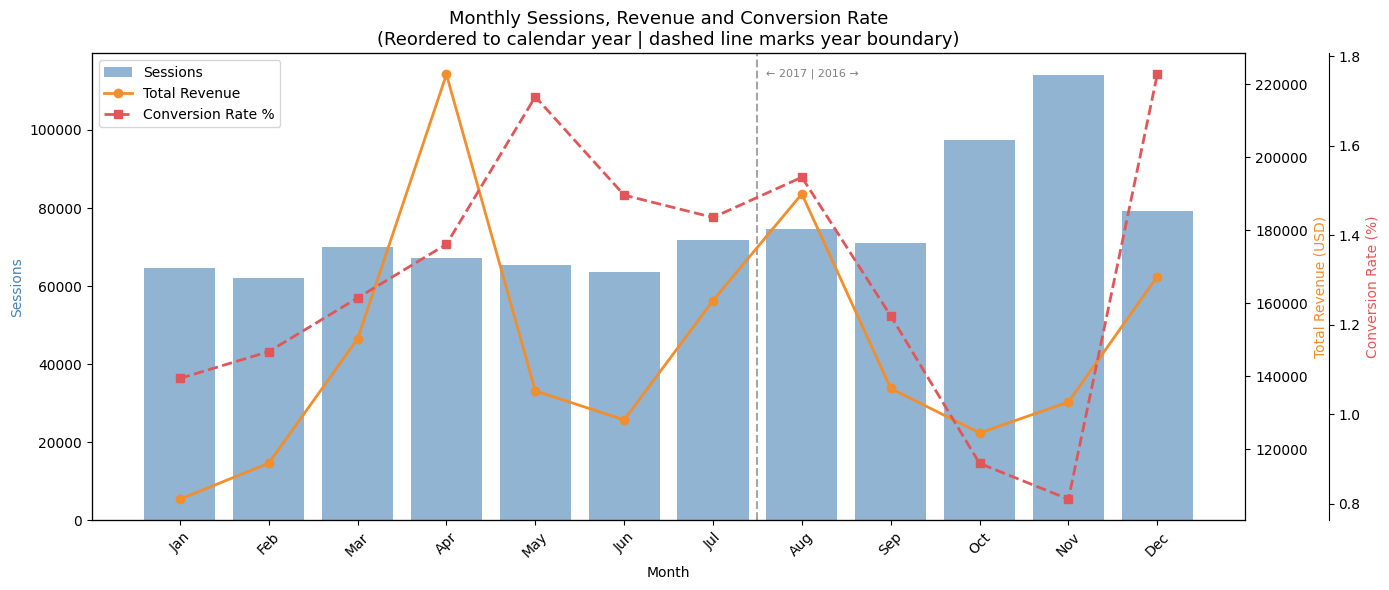

In [ ]:
# Extract month from date
df_sessions['month'] = df_sessions['date'].dt.to_period('M')

monthly = df_sessions.groupby('month').agg(
    sessions=('visitId', 'count'),
    converting_sessions=('transactions', 'count'),
    total_revenue=('totalTransactionRevenue', 'sum')
).reset_index()

monthly['conversion_rate'] = (monthly['converting_sessions'] / monthly['sessions'] * 100).round(2)
monthly['month_str'] = monthly['month'].astype(str)

# Reorder to calendar year
monthly['month_num'] = monthly['month'].dt.month
monthly = monthly[monthly['month_str'] != '2017-08']

# Split into two periods
aug_to_dec = monthly[monthly['month_str'] <= '2016-12'].sort_values('month_num')
jan_to_jul = monthly[monthly['month_str'] >= '2017-01'].sort_values('month_num')

# Combine — Jan to Jul first, then Aug to Dec
monthly_reordered = pd.concat([jan_to_jul, aug_to_dec])
monthly_reordered['month_label'] = monthly_reordered['month'].dt.strftime('%b')

fig, ax1 = plt.subplots(figsize=(14, 6))

x = range(len(monthly_reordered))

# Bars — session volume
ax1.bar(x, monthly_reordered['sessions'], color='steelblue', alpha=0.6, label='Sessions')
ax1.set_xlabel('Month')
ax1.set_ylabel('Sessions', color='steelblue')
ax1.set_xticks(list(x))
ax1.set_xticklabels(monthly_reordered['month_label'], rotation=45)

# Vertical line marking the cut between Jul 2017 and Aug 2016
ax1.axvline(x=6.5, color='grey', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.text(6.6, ax1.get_ylim()[1]*0.95, '← 2017 | 2016 →', fontsize=8, color='grey')

# Line — revenue on secondary axis
ax2 = ax1.twinx()
ax2.plot(list(x), monthly_reordered['total_revenue'], color='#f28e2b', linewidth=2, marker='o', label='Total Revenue')
ax2.set_ylabel('Total Revenue (USD)', color='#f28e2b')

# Line — conversion rate on third axis
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(list(x), monthly_reordered['conversion_rate'], color='#e15759', linewidth=2, marker='s', linestyle='--', label='Conversion Rate %')
ax3.set_ylabel('Conversion Rate (%)', color='#e15759')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left')

plt.title('Monthly Sessions, Revenue and Conversion Rate\n(Reordered to calendar year | dashed line marks year boundary)', fontsize=13)
plt.tight_layout()
plt.show()

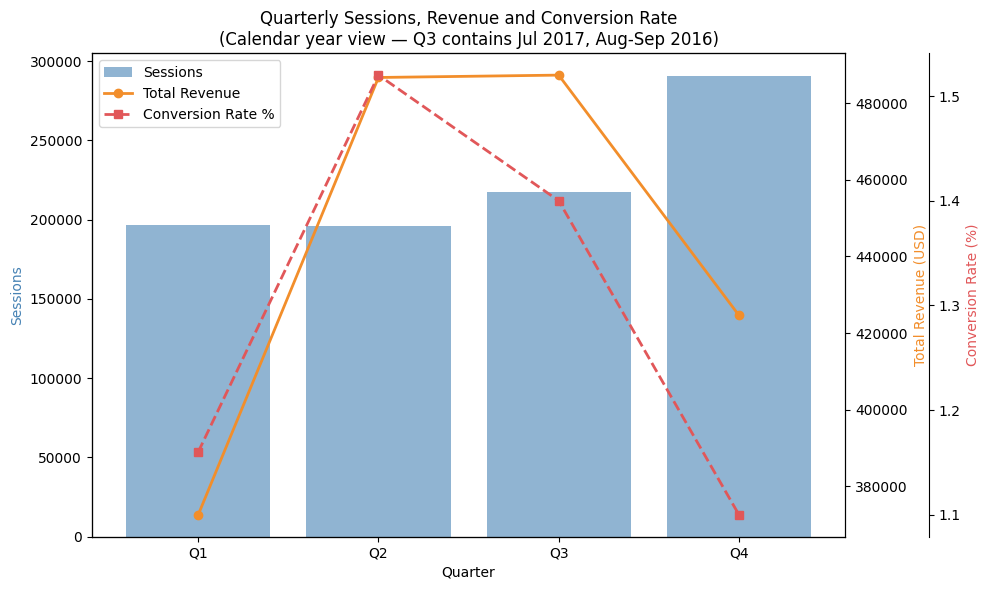

In [ ]:
# Assign manual quarters based on calendar month
def assign_quarter(date):
    month = date.month
    year = date.year
    if month in [1, 2, 3] and year == 2017:
        return 'Q1'
    elif month in [4, 5, 6] and year == 2017:
        return 'Q2'
    elif (month == 7 and year == 2017) or (month in [8, 9] and year == 2016):
        return 'Q3'
    elif month in [10, 11, 12] and year == 2016:
        return 'Q4'
    else:
        return None

df_sessions['calendar_quarter'] = df_sessions['date'].apply(assign_quarter)

# Drop any sessions not assigned to a quarter
df_quarterly = df_sessions[df_sessions['calendar_quarter'].notna()]

# Aggregate
quarterly_manual = df_quarterly.groupby('calendar_quarter').agg(
    sessions=('visitId', 'count'),
    converting_sessions=('transactions', 'count'),
    total_revenue=('totalTransactionRevenue', 'sum')
).reindex(['Q1', 'Q2', 'Q3', 'Q4']).reset_index()

# Recalculate conversion rate from raw counts
quarterly_manual['conversion_rate'] = (quarterly_manual['converting_sessions'] / quarterly_manual['sessions'] * 100).round(2)

fig, ax1 = plt.subplots(figsize=(10, 6))

x = range(len(quarterly_manual))

# Bars — session volume
ax1.bar(x, quarterly_manual['sessions'], color='steelblue', alpha=0.6, label='Sessions')
ax1.set_xlabel('Quarter')
ax1.set_ylabel('Sessions', color='steelblue')
ax1.set_xticks(list(x))
ax1.set_xticklabels(quarterly_manual['calendar_quarter'])

# Line — revenue on secondary axis
ax2 = ax1.twinx()
ax2.plot(list(x), quarterly_manual['total_revenue'], color='#f28e2b', linewidth=2, marker='o', label='Total Revenue')
ax2.set_ylabel('Total Revenue (USD)', color='#f28e2b')

# Line — conversion rate on third axis
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(list(x), quarterly_manual['conversion_rate'], color='#e15759', linewidth=2, marker='s', linestyle='--', label='Conversion Rate %')
ax3.set_ylabel('Conversion Rate (%)', color='#e15759')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left')

plt.title('Quarterly Sessions, Revenue and Conversion Rate\n(Calendar year view — Q3 contains Jul 2017, Aug-Sep 2016)', fontsize=12)
plt.tight_layout()
plt.show()

**Monthly view**
Revenue and conversion rate move closely together throughout the year, largely independently of session volume. Three conversion peaks are visible: April/May, August and December. Session volume follows a different pattern entirely — relatively stable through the year with a clear peak in October and November, when conversion and revenue are at their lowest.

**Quarterly view**
Aggregating to quarters confirms and sharpens the picture. Q2 (April-June) is the strategic peak — both revenue and conversion rate reach their highest point, strongly suggesting alignment with Google I/O, Google's annual developer conference held in May. Q3 (July-September) is the second strongest quarter on both metrics, suggesting sustained momentum through the summer. Q4 sees the highest session volume but the lowest conversion rate — however revenue holds up better than conversion rate in Q4, suggesting that while fewer sessions convert, those that do tend to spend more. Q1 is the weakest period overall on both revenue and conversion rate. The December conversion spike seen in the monthly view is absorbed by the weak October and November numbers at quarterly level.

**The session/revenue disconnect**
Session volume and revenue do not correlate. Traffic volume is therefore a misleading success metric for this store — the meaningful metric is conversion rate and expected revenue per session.

**Strategic implication**
High conversion rate combined with relatively lower sessions in Q2 and Q3 points to underleveraged periods. When the store's audience is naturally in a buying mindset, driving additional traffic would likely convert at the same elevated rate — making paid acquisition significantly more efficient in Q2 and Q3 than in Q4. The recommended approach: concentrate paid investment in Q2 and Q3, and in Q4 activate only in December where a genuine conversion spike exists within an otherwise weak Q4. Minimise paid spend in October and November where high traffic brings low intent.

#### 5.4.2 Revenue per Session by Channel Over Time

To examine whether channel over- and underperformance is structural or seasonal,
revenue per session is tracked monthly for each channel against the global average.
This is the temporal equivalent of the bubble chart from section 5.3 — using the
same metric (revenue generated per session, including non-converting sessions) to
allow direct comparison. Line style encodes the channel's overall performance
classification: solid lines for overperformers, dashed for mid-tier, dotted for
underperformers.

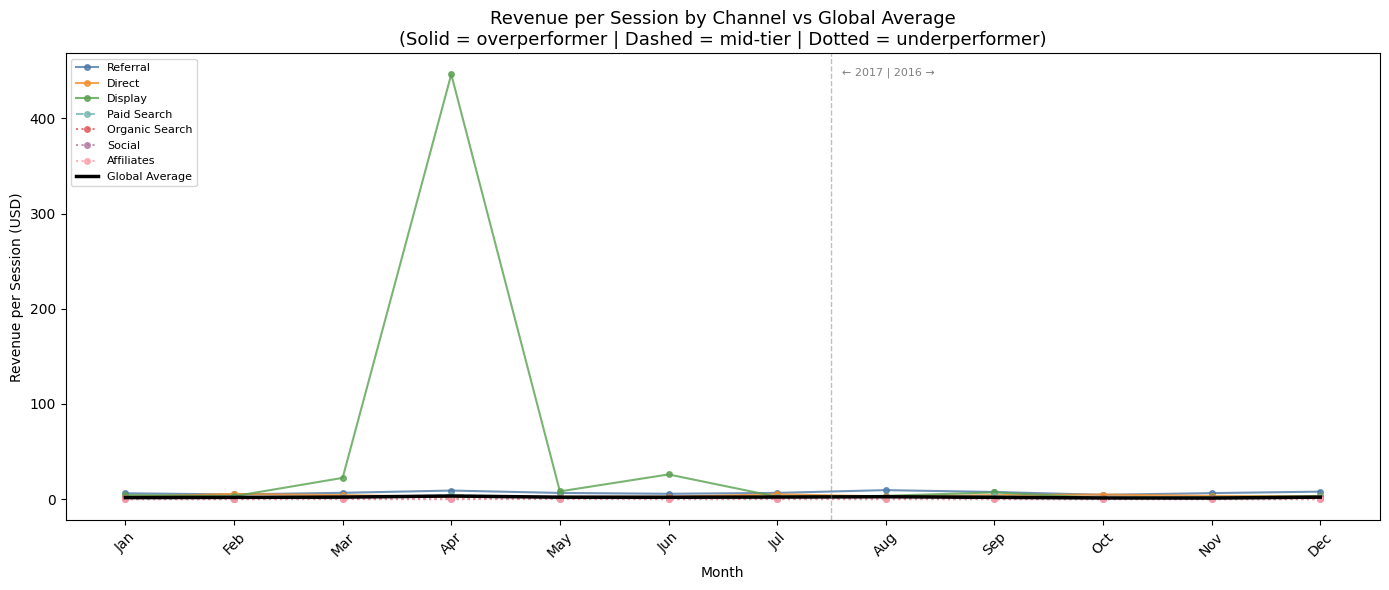

In [ ]:
channel_monthly_rev = df_sessions.groupby(['month', 'channelGrouping']).agg(
    sessions=('visitId', 'count'),
    total_revenue=('totalTransactionRevenue', 'sum')
).reset_index()

channel_monthly_rev['rev_per_session'] = (
    channel_monthly_rev['total_revenue'] / channel_monthly_rev['sessions']
).round(2)

channel_monthly_rev['month_str'] = channel_monthly_rev['month'].astype(str)
channel_monthly_rev = channel_monthly_rev[channel_monthly_rev['month_str'] != '2017-08']

month_order = [
    '2017-01', '2017-02', '2017-03',
    '2017-04', '2017-05', '2017-06',
    '2017-07', '2016-08', '2016-09',
    '2016-10', '2016-11', '2016-12'
]
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Global monthly average
global_rev = channel_monthly_rev.groupby('month_str').agg(
    sessions=('sessions', 'sum'),
    total_revenue=('total_revenue', 'sum')
).reset_index()
global_rev['rev_per_session'] = (global_rev['total_revenue'] / global_rev['sessions']).round(2)
global_rev = global_rev.set_index('month_str').reindex(month_order).reset_index()

# Channel style encoding
channel_styles = {
    'Referral':       {'linestyle': '-',  'color': '#4e79a7'},
    'Direct':         {'linestyle': '-',  'color': '#f28e2b'},
    'Display':        {'linestyle': '-',  'color': '#59a14f'},
    'Paid Search':    {'linestyle': '--', 'color': '#76b7b2'},
    'Organic Search': {'linestyle': ':',  'color': '#e15759'},
    'Social':         {'linestyle': ':',  'color': '#b07aa1'},
    'Affiliates':     {'linestyle': ':',  'color': '#ff9da7'},
}

fig, ax = plt.subplots(figsize=(14, 6))

for channel, style in channel_styles.items():
    data = channel_monthly_rev[channel_monthly_rev['channelGrouping'] == channel].copy()
    data = data.set_index('month_str').reindex(month_order).reset_index()
    ax.plot(range(len(month_order)), data['rev_per_session'],
            linestyle=style['linestyle'], color=style['color'],
            linewidth=1.5, marker='o', markersize=4, alpha=0.8, label=channel)

# Global average
ax.plot(range(len(month_order)), global_rev['rev_per_session'],
        color='black', linewidth=2.5, linestyle='-', label='Global Average')

ax.axvline(x=6.5, color='grey', linestyle='--', linewidth=1, alpha=0.5)
ax.text(6.6, ax.get_ylim()[1] * 0.95, '← 2017 | 2016 →', fontsize=8, color='grey')

ax.set_xticks(range(len(month_order)))
ax.set_xticklabels(month_labels, rotation=45)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue per Session (USD)')
ax.set_title('Revenue per Session by Channel vs Global Average\n'
             '(Solid = overperformer | Dashed = mid-tier | Dotted = underperformer)',
             fontsize=13)
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

#### Display — April Spike

Revenue per session for Display peaks sharply in April, dwarfing all other channels
and the global average in that month. Given that Display was already identified as an
overperformer in section 5.3 — the second highest conversion rate and highest median
order value across all channels — this spike suggests it may be solely responsible for
the April revenue peak visible in the overall monthly chart. However, Display is the
smallest channel by session volume at just 0.7% of total sessions. Before drawing
conclusions, the reliability of this spike needs to be assessed.

A single month's revenue per session figure for a low-volume channel can be heavily
distorted by a small number of high-value transactions. If Display had very few sessions
in April, the spike may reflect statistical noise rather than a genuine seasonal pattern.
Session count and transaction count for Display in April are examined to assess whether
the spike is a reliable signal.

In [ ]:
display_monthly = channel_monthly_rev[channel_monthly_rev['channelGrouping'] == 'Display'].copy()

display_transactions = df_sessions[df_sessions['channelGrouping'] == 'Display'].groupby('month').agg(
    sessions=('visitId', 'count'),
    transactions=('transactions', 'count'),
    total_revenue=('totalTransactionRevenue', 'sum')
).reset_index()

display_transactions['rev_per_session'] = (
    display_transactions['total_revenue'] / display_transactions['sessions']
).round(2)
display_transactions['month_str'] = display_transactions['month'].astype(str)
display_transactions = display_transactions[display_transactions['month_str'] != '2017-08']
display_transactions = display_transactions.set_index('month_str').reindex(month_order).reset_index()
display_transactions['month_label'] = month_labels

print(display_transactions[['month_label', 'sessions', 'transactions', 'total_revenue', 'rev_per_session']].to_string(index=False))

month_label  sessions  transactions  total_revenue  rev_per_session
        Jan       660            23        2865.55             4.34
        Feb       526            10        1629.86              3.1
        Mar       411             6        9184.70            22.35
        Apr       209             8       93243.75           446.14
        May       427             7        3492.32             8.18
        Jun       342            10        8878.21            25.96
        Jul       690            19        1748.30             2.53
        Aug       449            14        1577.02             3.51
        Sep       416            11        2948.11             7.09
        Oct       580             7         714.83             1.23
        Nov       686            13        1560.18             2.27
        Dec       827            14        2453.44             2.97


The April spike is driven by a very small number of transactions. Display recorded its
lowest session count of the year in April (209 sessions), with only 8 transactions
generating USD 93,243.75 in revenue — approximately USD 11,655 per transaction on
average, compared to January's 23 transactions averaging USD 124 each.

Two explanations are plausible: this could reflect a small number of random high-value
outliers inflating the monthly figure, or it could reflect genuine conference-driven
demand aligning with Google I/O in May — corporate or bulk purchases arriving through
Display in the lead-up month. To assess which explanation is more likely, the
probability that April's average transaction value could occur by chance is tested
formally.

#### Permutation Test on Display Spike

A permutation test is used to assess whether April's average Display transaction value
is statistically surprising given the full year's transaction distribution. The test
works by repeatedly drawing 8 random transactions from the full year's Display
transactions and recording the mean — simulating what April's average would look like
under random chance across 10,000 iterations. The p-value is the proportion of
simulations that produce a mean equal to or greater than April's observed mean. A low
p-value means April's result is unlikely to be random noise. A standard t-test is not
used here because the transaction value distribution is heavily right-skewed and the
sample is too small to assume normality.

In [ ]:
import numpy as np

# Get all Display converting sessions with revenue
display_transactions_raw = df_sessions[
    (df_sessions['channelGrouping'] == 'Display') &
    (df_sessions['totalTransactionRevenue'].notna())
].copy()

display_transactions_raw['month_str'] = display_transactions_raw['month'].astype(str)

# April transactions
april_values = display_transactions_raw[
    display_transactions_raw['month_str'] == '2017-04'
]['totalTransactionRevenue'].values

# All non-April transactions as the reference distribution
other_values = display_transactions_raw[
    display_transactions_raw['month_str'] != '2017-04'
]['totalTransactionRevenue'].values

observed_mean = april_values.mean()
n_april = len(april_values)

# Permutation test — 10,000 iterations
np.random.seed(42)
n_iterations = 10000
permuted_means = [
    np.random.choice(other_values, size=n_april, replace=True).mean()
    for _ in range(n_iterations)
]

p_value = np.mean(np.array(permuted_means) >= observed_mean)

print(f'April transactions:        {n_april}')
print(f'April mean order value:    USD {observed_mean:,.2f}')
print(f'Non-April mean order value: USD {other_values.mean():,.2f}')
print(f'P-value:                   {p_value:.4f}')

April transactions:        8
April mean order value:    USD 11,655.47
Non-April mean order value: USD 276.81
P-value:                   0.0000


The permutation test result is unambiguous. Across 10,000 random draws of 8
transactions from the full-year Display distribution, not a single simulation
produced a mean order value as high as April's USD 11,655.47 — compared to a
non-April mean of USD 276.81. The p-value of 0.0000 means the probability of
April's result occurring by random chance is effectively zero.

This rules out the random outlier explanation. April's Display revenue is
statistically extraordinary and almost certainly reflects a genuine demand event
rather than noise. Combined with the established Q2 alignment with Google I/O,
the most plausible interpretation is that Display captured a small number of
high-value corporate or bulk purchases in the lead-up to the conference — a
pattern that would be invisible in session volume terms but significant in revenue
terms.

The strategic implication is notable: a channel generating only 0.7% of sessions
produced a statistically anomalous revenue event that meaningfully impacted the
store's monthly totals. This warrants monitoring Display performance around Q2
in future years to determine whether the pattern repeats.

#### Chart without Display

The chart below reproduces the revenue per session analysis with Display removed.
The remaining six channels and global average are plotted using the same line style
encoding — solid for overperformers, dashed for mid-tier, dotted for underperformers.

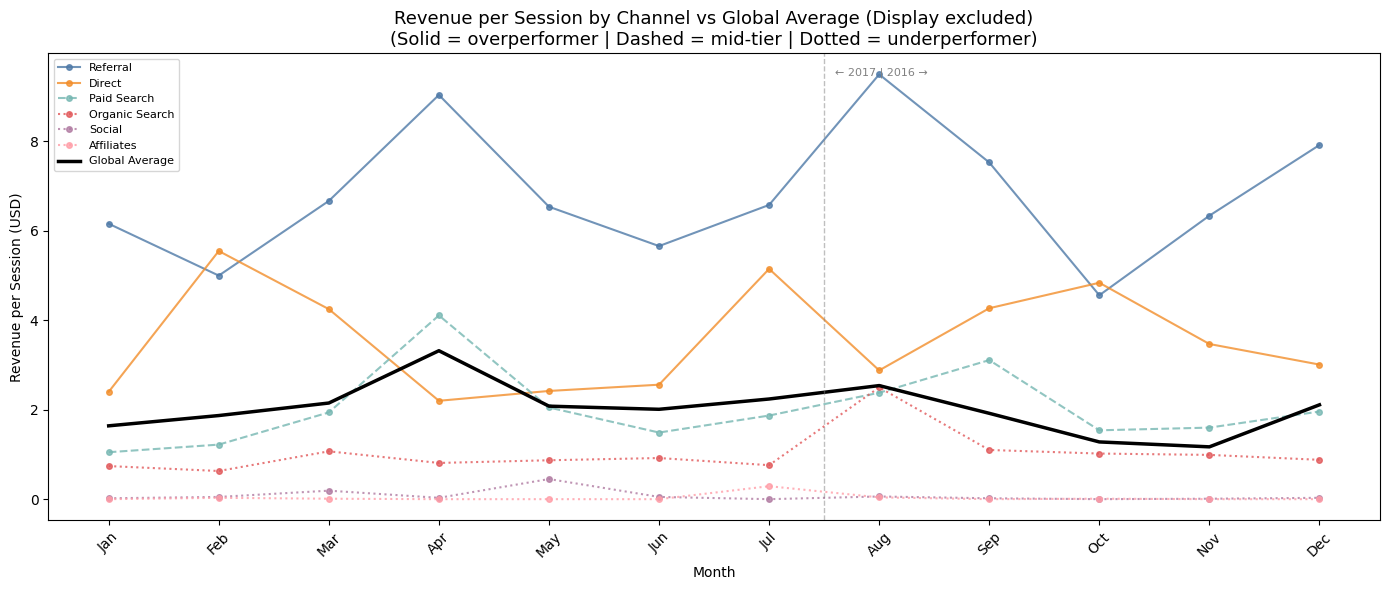

In [ ]:
channel_styles_no_display = {
    'Referral':       {'linestyle': '-',  'color': '#4e79a7'},
    'Direct':         {'linestyle': '-',  'color': '#f28e2b'},
    'Paid Search':    {'linestyle': '--', 'color': '#76b7b2'},
    'Organic Search': {'linestyle': ':',  'color': '#e15759'},
    'Social':         {'linestyle': ':',  'color': '#b07aa1'},
    'Affiliates':     {'linestyle': ':',  'color': '#ff9da7'},
}

fig, ax = plt.subplots(figsize=(14, 6))

for channel, style in channel_styles_no_display.items():
    data = channel_monthly_rev[channel_monthly_rev['channelGrouping'] == channel].copy()
    data = data.set_index('month_str').reindex(month_order).reset_index()
    ax.plot(range(len(month_order)), data['rev_per_session'],
            linestyle=style['linestyle'], color=style['color'],
            linewidth=1.5, marker='o', markersize=4, alpha=0.8, label=channel)

ax.plot(range(len(month_order)), global_rev['rev_per_session'],
        color='black', linewidth=2.5, linestyle='-', label='Global Average')

ax.axvline(x=6.5, color='grey', linestyle='--', linewidth=1, alpha=0.5)
ax.text(6.6, ax.get_ylim()[1] * 0.95, '← 2017 | 2016 →', fontsize=8, color='grey')

ax.set_xticks(range(len(month_order)))
ax.set_xticklabels(month_labels, rotation=45)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue per Session (USD)')
ax.set_title('Revenue per Session by Channel vs Global Average (Display excluded)\n'
             '(Solid = overperformer | Dashed = mid-tier | Dotted = underperformer)',
             fontsize=13)
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

Though the chart confirms that over- and underperformance itself is largely structural
rather than seasonal, there are strong seasonal patterns within overperforming channels.
Key observations by group:

**Underperformers — consistently below average all year**
Organic Search, Social and Affiliates remain below the global average every month
without exception. Organic Search comes closest to average in August but never crosses
it. Social and Affiliates are effectively flat near zero year-round, generating
negligible revenue per session regardless of season. There is no month where
concentrating spend on these channels would be justified by this metric.

**Paid Search — mid-tier with seasonal windows**
Paid Search sits slightly below average for most of the year but crosses above in
April, September, and October–November. This is the only underperforming or mid-tier
channel that shows genuine seasonal upside — suggesting there are specific windows
where paid investment becomes more efficient.

**Direct — high performer with significant variation**
Direct sits between Paid Search and Referral overall but shows the most month-to-month
variation of any channel. It peaks sharply in February/March, July and October, and
spends most of the year above or near the global average. The notable exception is
April, where Direct dips below average precisely when Referral peaks — suggesting
that conference-period demand flows disproportionately through Referral rather than
Direct.

**Referral — structural overperformer with seasonal peaks**
Referral is the highest-performing channel year-round and shows an almost inverted
pattern to Direct. Its strongest months are April and August, corresponding exactly
to Direct's weakest periods, with December as a third peak. The April and August
peaks align with the Google I/O period and summer momentum identified in the broader
temporal analysis, reinforcing the interpretation that event- and season-driven demand
arrives predominantly through referral sources — external links, press coverage or
partner sites — rather than direct navigation. The December peak is notable given that
overall session volume is low that month, suggesting a shift toward high-intent buyers
arriving via referral in the run-up to the holidays.

**The Direct–Referral inverse relationship**
The consistent alternation between Direct and Referral across the year is the most
strategically interesting finding in this section. It suggests these two channels are
drawing from different audience behaviours — habitual buyers navigating directly vs
externally referred buyers arriving with purchase intent — and that their relative
strength shifts with seasonal context.

 #### Summary — Temporal Patterns

Three consistent patterns emerge from the temporal analysis.

**Revenue and conversion move together, sessions do not.** Session volume is a
misleading success metric for this store — traffic peaks in October and November
coincide with the weakest conversion rates of the year. The meaningful metric is
revenue per session, which tracks closely with conversion rate throughout the year.

**Q2 is the strategic peak.** April through June shows the highest conversion rates
and revenue per session across both the overall store and the highest-performing
channels. This aligns with Google I/O in May and is reinforced by Display's
statistically anomalous April revenue event — suggesting that conference-driven demand
is a genuine and recurring strategic factor worth planning around.

**Over- and underperformance is structural, but seasonal patterns exist within
overperforming channels.** Underperforming channels — Social, Affiliates and Organic
Search — remain below average every month without exception. Within the overperforming
group, Direct and Referral show a consistent inverse seasonal relationship, suggesting
they serve different audience behaviours that shift in relative strength across the
year. Paid Search is the only mid-tier channel with identifiable seasonal windows where
it crosses above average — April, September and October–November.

---
*Findings and recommendations across all sections are synthesised in the Executive
Summary at the top of this notebook.*

<small>**Further analysis:** This notebook focuses on session-level channel performance.
Two natural extensions are out of scope here: referral path analysis (identifying which
specific sites drive high-value Referral traffic, actionable for partnership and PR
decisions) and hit-level analysis (page behaviour, funnel drop-off and product
performance using the hit-level extraction architected in Section 2).</small>